[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/Univariate_Temperature_RNN.ipynb)

🔴
<!-- 🎙 DAVE TALKING POINTS — M4 · 6 — Univariate RNN Pt 1: the 3-D tensor and split_sequence
- Drop the window feature engineering - hand the RNN the raw sequence as a 3-D tensor and let it learn the temporal features (like the ConvNet learned image features).
- 3,650 daily temperatures, look-back 10 -> 3,640 samples of 10 x 1. split_sequence: [1,2,3] -> 4, [2,3,4] -> 5, oldest to newest.
- The reshape to add the trailing 1 is where 90% of RNN errors live - do it slowly on camera.
- Chronological 90/10: 3,276 train / 364 test.
-->


# Univariate Temperature Example (RNN)
-------------------------

**Dr. Dave Wanik - University of Connecticut**

Let's see if we can predict the next day's temperature as a function of N previous days.

Each of these is an example of a many-to-one classification (using a single feature with a lookback of N). This is the among the most tasks that need to be done with time series problems.

You could also try to implement a one-to-one by simply shifting the column by -1 then re-running (this is different than the baseline model we show at the end).

In [1]:
# standard modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# RNN-specific modules
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report,accuracy_score
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, GRU, LSTM
from tensorflow.keras.callbacks import EarlyStopping

# reproducibility: same seed every run (numbers on CPU match exactly; a GPU may drift a little)
import keras
keras.utils.set_random_seed(5509)


## Read in data
Check for missing values, make some plots.

In [2]:
# Dataset initially sourced from jbrownlee’s GitHub repository:
# url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv'
# Link to the data file on Github
url = "https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/refs/heads/main/OPIM5509_Module4_Files/data/daily-min-temperatures.csv"

# read the data
df = pd.read_csv(url)
print(df.info())
df.head(n=15) # nice complete data! this will allow us to check our work later

<class 'pandas.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3650 non-null   str    
 1   Temp    3650 non-null   float64
dtypes: float64(1), str(1)
memory usage: 92.8 KB
None


,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8
5,1981-01-06,15.8
6,1981-01-07,15.8
7,1981-01-08,17.4
8,1981-01-09,21.8
9,1981-01-10,20.0


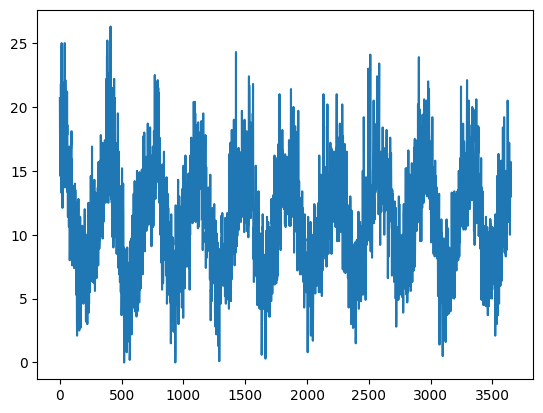

In [3]:
# visualize the data
df['Temp'].plot()
plt.show()

In [4]:
# prep data for modeling (univariate)
# link: https://machinelearningmastery.com/how-to-develop-lstm-models-for-time-series-forecasting/

# univariate data preparation
from numpy import array

# split a univariate sequence into samples
def split_sequence(sequence, n_steps):
	X, y = list(), list()
	for i in range(len(sequence)):
		# find the end of this pattern
		end_ix = i + n_steps
		# check if we are beyond the sequence
		if end_ix > len(sequence)-1:
			break
		# gather input and output parts of the pattern
		seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
		X.append(seq_x)
		y.append(seq_y)
	return array(X), array(y)

In [5]:
# here's an example of how this script works
# define input sequence
raw_seq = [10, 20, 30, 40, 50, 60, 70, 80, 90]
# choose a number of time steps
n_steps = 3
# split into samples
X, y = split_sequence(raw_seq, n_steps)
# summarize the data
for i in range(len(X)):
	print(X[i], y[i])

[10 20 30] 40
[20 30 40] 50
[30 40 50] 60
[40 50 60] 70
[50 60 70] 80
[60 70 80] 90


In [6]:
# all we need to do is decide on is n_steps (what our lookback period is)
# since we have a bunch of data, why not n_steps=10? then try 30 later on.
n_steps = 10
raw_seq = df['Temp'] # the second column, where the data is. UPDATE THIS ON YOUR DATA!
# let's ignore the date column and just use the temperature data
X, y = split_sequence(raw_seq, n_steps)

In [7]:
# check out X and y shape
print(df.shape)
print(X.shape)

(3650, 2)
(3640, 10)


In [8]:
# take a peak at what it did
print(X[0])
print(y[0])

# scroll up and make sure you understand this!
# y is a function of X (the previous n_steps observations!)

[20.7 17.9 18.8 14.6 15.8 15.8 15.8 17.4 21.8 20. ]
16.2


In [9]:
# now we reshape the data into a 3D array
# reshape from [samples, timesteps] into [samples, timesteps, features]
n_features = 1 # this is 1 because it is univariate data
X = X.reshape((X.shape[0], X.shape[1], n_features))
X.shape

(3640, 10, 1)

In [10]:
# split the data into train and test partitions
# we will use 90% of the data for train, and 10% for validation
train_pct_index = int(0.9 * len(X))
X_train, X_test = X[:train_pct_index], X[train_pct_index:]
y_train, y_test = y[:train_pct_index], y[train_pct_index:]

# pretty slick way of splitting your data using slicing!
# notice how we didn't do any shuffling (we don't want temporal leakage! keeps time series intact)

In [11]:
# check the shape to be sure
print(X.shape, X_train.shape, X_test.shape)

# verify that this all adds up!

(3640, 10, 1) (3276, 10, 1) (364, 10, 1)


In [12]:
# peak at it!
X_train[0]

array([[20.7],
       [17.9],
       [18.8],
       [14.6],
       [15.8],
       [15.8],
       [15.8],
       [17.4],
       [21.8],
       [20. ]])

In [13]:
y[0]

np.float64(16.2)

In [14]:
# if we wanted to, we could do some scaling/normalization here, would not hurt!

🔴
<!-- 🎙 DAVE TALKING POINTS — M4 · 7 — Univariate RNN Pt 2: fit SimpleRNN, then LSTM, then beat the baselines
- Confirm the tensor (3640, 10, 1); inherit n_steps and n_features FROM THE SHAPE; 30 red dots -> 31x30+30 params, spinning 10 times.
- Linear output, MSE loss, MAE tracked, early stopping on val_loss (20% of train as validation).
- SimpleRNN MAE ~1.77 vs the window method's ~1.76 - the same. One-word swap to LSTM -> ~1.74.
- The sermon: beat MEAN-ONLY and PERSISTENCE (shift-1, ~2.02) or you've learned nothing. A shifted copy looks great on a plot - always pair metric + scatter + time-series.
-->


# RNN one layer model

In [15]:
# samples, lookback, features
# samples = original rows in df - lookback period
# 3640 = 3650 - 10
X.shape

(3640, 10, 1)

In [16]:
# store these features for modeling
n_features = X.shape[2]
n_steps = X.shape[1]

print(n_steps, n_features)

10 1


In [17]:

# now let's build a model

# since this is a univariate problem, n_features will be 1 (we also defined this before, but this is a better way)
n_features = X.shape[2] # 1 green dot
n_steps = X.shape[1] # 10 steps (not shown in the animation - this is how many times it loops)

# define model
model = Sequential()
model.add(SimpleRNN(30, input_shape=(n_steps,n_features), activation='relu')) # 30 red dots
model.add(Dense(1, activation='linear'))
model.compile(optimizer='adam', loss='mse',metrics=['mae'])
model.summary()

es = EarlyStopping(monitor='val_loss', mode='min',
                   patience=10,
                   verbose=1,
                   restore_best_weights=True)

# fit model (uses early stopping)
model.fit(X_train, y_train,
          epochs=500,
          batch_size=5,
          validation_split=0.2, # val is a random 20% of the train data since we set shuffle = True
          verbose=1,
          callbacks=[es],
          shuffle=True)

C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 30)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 991 (3.87 KB)

 Trainable params: 991 (3.87 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 48:15 6s/step - loss: 92.7630 - mae: 9.0670

 13/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 29.0553 - mae: 4.2126  

 25/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 19.8094 - mae: 3.4080

 37/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 15.9959 - mae: 3.0202

 49/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 14.3321 - mae: 2.8792

 61/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 13.1240 - mae: 2.7745

 73/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 12.2441 - mae: 2.6898

 84/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 11.6756 - mae: 2.6542

 96/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 11.1295 - mae: 2.6060

108/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 10.5349 - mae: 2.5205

119/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 10.2915 - mae: 2.4875

130/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 10.1726 - mae: 2.4860

141/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 9.8468 - mae: 2.4390 

152/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 9.5680 - mae: 2.4101

163/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 9.3576 - mae: 2.3827

174/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 9.0959 - mae: 2.3414

185/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 9.0458 - mae: 2.3375

196/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.9116 - mae: 2.3210

206/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.9366 - mae: 2.3244

217/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.8029 - mae: 2.3107

228/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.5762 - mae: 2.2738

239/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.5521 - mae: 2.2710

251/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.4659 - mae: 2.2599

263/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.3088 - mae: 2.2336

275/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.2358 - mae: 2.2250

287/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.1204 - mae: 2.2075

299/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.0266 - mae: 2.1954

311/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.0643 - mae: 2.2026

323/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.0574 - mae: 2.2030

334/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.9473 - mae: 2.1896

345/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.9378 - mae: 2.1940

357/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.8564 - mae: 2.1831

368/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.8426 - mae: 2.1833

379/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.7838 - mae: 2.1745

390/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.7361 - mae: 2.1679

401/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.6980 - mae: 2.1634

411/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.6379 - mae: 2.1577

422/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.6090 - mae: 2.1518

433/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.5769 - mae: 2.1485

443/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.6536 - mae: 2.1537

450/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.6365 - mae: 2.1529

461/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.5707 - mae: 2.1443

472/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.5053 - mae: 2.1343

483/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.4370 - mae: 2.1255

494/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.4089 - mae: 2.1220

505/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.3687 - mae: 2.1172

515/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.3286 - mae: 2.1119

524/524 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 7.3304 - mae: 2.1151 - val_loss: 5.6334 - val_mae: 1.8702


Epoch 2/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 9:38 1s/step - loss: 13.2829 - mae: 3.3985

 13/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 7.5271 - mae: 2.2327  

 25/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 7.6963 - mae: 2.2545

 38/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 7.1824 - mae: 2.1775

 51/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.7985 - mae: 2.2437

 63/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.6641 - mae: 2.2299

 73/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.5630 - mae: 2.2221

 84/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.5618 - mae: 2.2403

 95/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.5667 - mae: 2.2447

105/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.3121 - mae: 2.1962

116/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.4343 - mae: 2.2035

128/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.3970 - mae: 2.2022

139/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.3631 - mae: 2.1906

150/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.2553 - mae: 2.1790

160/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.1381 - mae: 2.1616

169/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.0910 - mae: 2.1477

179/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.0272 - mae: 2.1339

190/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.0988 - mae: 2.1408

201/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.0443 - mae: 2.1281

213/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.0879 - mae: 2.1333

225/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9659 - mae: 2.1112

236/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9015 - mae: 2.1011

248/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9790 - mae: 2.1097

259/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8719 - mae: 2.0889

271/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8019 - mae: 2.0723

283/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8009 - mae: 2.0715

294/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7426 - mae: 2.0618

305/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7482 - mae: 2.0645

315/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.7823 - mae: 2.0684

327/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.8099 - mae: 2.0722

338/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.7818 - mae: 2.0693

349/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.7660 - mae: 2.0707

360/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.7311 - mae: 2.0651

371/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.7655 - mae: 2.0706

382/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.6973 - mae: 2.0606

393/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.7158 - mae: 2.0634

404/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.6860 - mae: 2.0579

416/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.6775 - mae: 2.0565

427/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.6461 - mae: 2.0501

438/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.7068 - mae: 2.0582

450/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.7296 - mae: 2.0563

461/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.6811 - mae: 2.0489

470/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.6488 - mae: 2.0429

480/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5906 - mae: 2.0343

490/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.6019 - mae: 2.0367

499/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5690 - mae: 2.0308

510/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5384 - mae: 2.0270

520/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5335 - mae: 2.0262

524/524 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 6.5357 - mae: 2.0275 - val_loss: 5.5176 - val_mae: 1.8575


Epoch 3/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 37s 72ms/step - loss: 13.9532 - mae: 3.4841

 11/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.7519 - mae: 2.2522   

 20/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.9582 - mae: 2.1219

 28/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.2014 - mae: 2.1852

 39/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.1264 - mae: 2.1592

 50/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.5275 - mae: 2.2075

 61/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.4220 - mae: 2.1868

 70/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.4227 - mae: 2.1941

 81/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.4349 - mae: 2.2156

 91/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.2656 - mae: 2.1926

100/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.2443 - mae: 2.1878

110/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.4231 - mae: 2.1913

120/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.2481 - mae: 2.1716

129/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.2553 - mae: 2.1768

139/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.2074 - mae: 2.1641

150/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.1179 - mae: 2.1544

162/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.0380 - mae: 2.1391

173/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9353 - mae: 2.1150

183/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9086 - mae: 2.1114

193/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9041 - mae: 2.1023

204/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8850 - mae: 2.0993

215/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9136 - mae: 2.1016

225/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8160 - mae: 2.0824

236/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7509 - mae: 2.0719

246/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8036 - mae: 2.0767

256/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7533 - mae: 2.0657

267/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6995 - mae: 2.0538

278/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6762 - mae: 2.0523

289/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6047 - mae: 2.0345

298/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5730 - mae: 2.0306

308/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6115 - mae: 2.0375

318/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6744 - mae: 2.0466

329/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6271 - mae: 2.0383

341/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.6275 - mae: 2.0437

352/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.6240 - mae: 2.0453

362/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.6235 - mae: 2.0443

372/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.6305 - mae: 2.0457

383/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5459 - mae: 2.0325

394/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5826 - mae: 2.0395

406/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5479 - mae: 2.0333

416/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5512 - mae: 2.0328

427/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5242 - mae: 2.0272

438/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5791 - mae: 2.0342

448/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5916 - mae: 2.0299

458/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5673 - mae: 2.0268

468/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5204 - mae: 2.0185

478/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4813 - mae: 2.0130

488/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4687 - mae: 2.0109

496/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4522 - mae: 2.0083

506/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4313 - mae: 2.0054

516/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3954 - mae: 1.9995

521/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4190 - mae: 2.0042

524/524 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 6.4194 - mae: 2.0048 - val_loss: 5.4650 - val_mae: 1.8500


Epoch 4/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 30s 58ms/step - loss: 14.2693 - mae: 3.5364

 12/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.4826 - mae: 2.2377   

 23/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.2325 - mae: 2.1880

 34/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0301 - mae: 2.1568

 45/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.3454 - mae: 2.1988

 56/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.5681 - mae: 2.2117

 66/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.3812 - mae: 2.1889

 78/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.4646 - mae: 2.2113

 88/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.2836 - mae: 2.1922

 99/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.2542 - mae: 2.1911

110/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.3837 - mae: 2.1854

121/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.1969 - mae: 2.1645

132/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.2413 - mae: 2.1720

142/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.1186 - mae: 2.1503

153/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.0662 - mae: 2.1488

164/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9483 - mae: 2.1247

174/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8570 - mae: 2.1024

185/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8978 - mae: 2.1035

194/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8657 - mae: 2.0962

205/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9088 - mae: 2.0989

215/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8456 - mae: 2.0903

227/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7108 - mae: 2.0639

238/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7516 - mae: 2.0686

249/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7601 - mae: 2.0703

255/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6842 - mae: 2.0553

266/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6052 - mae: 2.0404

276/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6127 - mae: 2.0411

286/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5664 - mae: 2.0307

297/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4995 - mae: 2.0192

306/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5115 - mae: 2.0220

315/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5562 - mae: 2.0282

324/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.6230 - mae: 2.0377

335/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5580 - mae: 2.0289

341/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5631 - mae: 2.0327

349/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5545 - mae: 2.0329

359/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5329 - mae: 2.0293

370/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5720 - mae: 2.0353

374/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5554 - mae: 2.0332

385/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4876 - mae: 2.0219

394/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5248 - mae: 2.0289

404/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5034 - mae: 2.0233

415/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4440 - mae: 2.0165

426/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4760 - mae: 2.0173

435/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4816 - mae: 2.0190

445/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5368 - mae: 2.0194

455/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5284 - mae: 2.0200

466/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4846 - mae: 2.0107

477/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4370 - mae: 2.0039

488/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4213 - mae: 2.0012

499/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3989 - mae: 1.9975

510/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3685 - mae: 1.9936

520/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3704 - mae: 1.9938

524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 6.3730 - mae: 1.9951 - val_loss: 5.4500 - val_mae: 1.8477


Epoch 5/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 36s 69ms/step - loss: 14.3831 - mae: 3.5537

 13/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9777 - mae: 2.1445   

 25/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.2756 - mae: 2.1735

 36/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.1127 - mae: 2.1656

 47/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.3974 - mae: 2.2049

 58/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.4182 - mae: 2.1928

 69/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.2889 - mae: 2.1760

 80/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.3706 - mae: 2.1984

 92/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.2598 - mae: 2.1833

103/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.1212 - mae: 2.1650

114/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.2385 - mae: 2.1627

123/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.1767 - mae: 2.1534

134/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.2566 - mae: 2.1740

145/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.0184 - mae: 2.1321

155/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9824 - mae: 2.1310

164/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9120 - mae: 2.1154

174/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8248 - mae: 2.0931

185/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8643 - mae: 2.0936

197/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8046 - mae: 2.0831

209/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8463 - mae: 2.0852

219/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7761 - mae: 2.0764

230/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6511 - mae: 2.0509

241/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7039 - mae: 2.0522

252/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7151 - mae: 2.0585

262/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6206 - mae: 2.0380

269/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5768 - mae: 2.0295

280/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5498 - mae: 2.0272

291/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5016 - mae: 2.0146

301/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4688 - mae: 2.0108

312/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5338 - mae: 2.0199

324/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5966 - mae: 2.0293

334/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5301 - mae: 2.0202

346/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5317 - mae: 2.0244

357/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5021 - mae: 2.0215

369/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5522 - mae: 2.0271

381/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4763 - mae: 2.0162

392/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4986 - mae: 2.0205

403/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4782 - mae: 2.0154

414/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4338 - mae: 2.0111

426/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4540 - mae: 2.0101

437/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4747 - mae: 2.0135

448/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5089 - mae: 2.0114

459/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4825 - mae: 2.0078

471/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4278 - mae: 1.9977

483/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3895 - mae: 1.9931

495/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3836 - mae: 1.9911

507/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3477 - mae: 1.9860

518/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3296 - mae: 1.9834

524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 6.3511 - mae: 1.9876 - val_loss: 5.4250 - val_mae: 1.8452


Epoch 6/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 19:38 2s/step - loss: 13.9898 - mae: 3.5234

 13/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7946 - mae: 2.1091   

 24/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9954 - mae: 2.1485

 36/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9808 - mae: 2.1480

 47/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.2148 - mae: 2.1809

 58/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.3097 - mae: 2.1802

 69/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.2161 - mae: 2.1678

 78/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.3393 - mae: 2.1918

 89/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.1501 - mae: 2.1710

 98/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.2057 - mae: 2.1846

109/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0704 - mae: 2.1529

120/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.1106 - mae: 2.1501

131/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.1348 - mae: 2.1545

141/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.0315 - mae: 2.1347

153/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9979 - mae: 2.1367

165/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8563 - mae: 2.1081

176/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7804 - mae: 2.0856

187/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8040 - mae: 2.0832

199/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7852 - mae: 2.0778

210/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7941 - mae: 2.0763

221/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7586 - mae: 2.0714

232/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6008 - mae: 2.0425

243/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6577 - mae: 2.0471

254/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6324 - mae: 2.0441

265/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5390 - mae: 2.0256

275/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5280 - mae: 2.0229

286/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4942 - mae: 2.0152

297/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4301 - mae: 2.0042

306/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4454 - mae: 2.0070

317/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5124 - mae: 2.0183

328/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5153 - mae: 2.0159

339/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5064 - mae: 2.0177

349/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4895 - mae: 2.0174

360/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4653 - mae: 2.0145

371/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5029 - mae: 2.0196

383/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4265 - mae: 2.0074

394/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4681 - mae: 2.0152

406/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4341 - mae: 2.0091

416/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4413 - mae: 2.0091

427/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4149 - mae: 2.0039

439/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4510 - mae: 2.0068

450/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4825 - mae: 2.0071

461/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4357 - mae: 1.9992

472/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3943 - mae: 1.9918

483/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3568 - mae: 1.9868

495/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3518 - mae: 1.9849

506/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3259 - mae: 1.9813

514/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3115 - mae: 1.9797

524/524 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 6.3232 - mae: 1.9823 - val_loss: 5.4108 - val_mae: 1.8434


Epoch 7/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 29s 56ms/step - loss: 13.9277 - mae: 3.5068

 13/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.7469 - mae: 2.1023   

 24/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9698 - mae: 2.1433

 35/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0212 - mae: 2.1464

 46/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0818 - mae: 2.1618

 57/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.3637 - mae: 2.1882

 67/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.2224 - mae: 2.1662

 78/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.3475 - mae: 2.1933

 88/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.1950 - mae: 2.1787

 97/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.2607 - mae: 2.1960

107/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.1004 - mae: 2.1565

116/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.1855 - mae: 2.1616

127/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.1114 - mae: 2.1493

137/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.1132 - mae: 2.1512

146/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9849 - mae: 2.1297

155/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9537 - mae: 2.1277

166/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8893 - mae: 2.1112

171/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8467 - mae: 2.0975

181/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7653 - mae: 2.0840

189/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8215 - mae: 2.0852

200/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7787 - mae: 2.0750

211/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7670 - mae: 2.0713

222/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7329 - mae: 2.0671

233/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6153 - mae: 2.0436

244/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6469 - mae: 2.0460

254/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6201 - mae: 2.0422

266/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5193 - mae: 2.0229

277/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5239 - mae: 2.0238

289/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4510 - mae: 2.0064

301/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4173 - mae: 2.0028

312/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4804 - mae: 2.0112

325/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5396 - mae: 2.0200

338/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5022 - mae: 2.0158

351/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4950 - mae: 2.0188

363/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4813 - mae: 2.0157

375/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4760 - mae: 2.0153

387/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4165 - mae: 2.0055

399/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4310 - mae: 2.0075

411/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4103 - mae: 2.0062

422/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4110 - mae: 2.0016

434/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4001 - mae: 1.9998

445/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4602 - mae: 2.0016

457/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4479 - mae: 2.0009

469/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3846 - mae: 1.9886

481/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3465 - mae: 1.9841

493/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3343 - mae: 1.9815

504/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2986 - mae: 1.9768

515/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2814 - mae: 1.9730

524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 6.3054 - mae: 1.9784 - val_loss: 5.4010 - val_mae: 1.8418


Epoch 8/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 41s 79ms/step - loss: 13.5658 - mae: 3.4487

 13/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.6839 - mae: 2.0930   

 24/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.9232 - mae: 2.1347

 35/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9720 - mae: 2.1370

 45/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0403 - mae: 2.1563

 53/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.1264 - mae: 2.1402

 63/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.2575 - mae: 2.1657

 70/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.1933 - mae: 2.1581

 80/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.2429 - mae: 2.1806

 89/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0937 - mae: 2.1598

 96/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.2202 - mae: 2.1860

106/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0807 - mae: 2.1523

116/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.1375 - mae: 2.1516

126/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0956 - mae: 2.1424

138/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0224 - mae: 2.1300

149/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9476 - mae: 2.1207

160/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8497 - mae: 2.1090

171/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8163 - mae: 2.0894

183/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7532 - mae: 2.0770

194/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7609 - mae: 2.0707

203/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7217 - mae: 2.0634

213/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7637 - mae: 2.0692

224/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6566 - mae: 2.0488

235/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5498 - mae: 2.0299

246/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6255 - mae: 2.0406

257/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5728 - mae: 2.0293

262/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5394 - mae: 2.0228

273/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4809 - mae: 2.0107

283/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4578 - mae: 2.0079

287/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4401 - mae: 2.0040

297/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3928 - mae: 1.9960

302/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4171 - mae: 2.0012

312/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4542 - mae: 2.0048

318/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5019 - mae: 2.0129

328/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4792 - mae: 2.0073

332/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4598 - mae: 2.0057

341/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4607 - mae: 2.0086

350/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.4583 - mae: 2.0099

359/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.4322 - mae: 2.0058

368/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.4483 - mae: 2.0082

376/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.4376 - mae: 2.0064

386/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3857 - mae: 1.9986

396/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.4263 - mae: 2.0046

405/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3963 - mae: 1.9994

416/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3989 - mae: 1.9993

426/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3775 - mae: 1.9944

437/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3921 - mae: 1.9968

447/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.4183 - mae: 1.9932

458/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.4033 - mae: 1.9909

468/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3569 - mae: 1.9826

477/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3316 - mae: 1.9796

488/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3172 - mae: 1.9770

499/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2959 - mae: 1.9735

509/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2637 - mae: 1.9694

521/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2736 - mae: 1.9709

524/524 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 6.2772 - mae: 1.9721 - val_loss: 5.3907 - val_mae: 1.8398


Epoch 9/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 33s 64ms/step - loss: 13.4774 - mae: 3.4210

 11/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9808 - mae: 2.1253   

 22/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7310 - mae: 2.0933

 30/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8084 - mae: 2.1159

 37/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.8315 - mae: 2.1156

 43/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.8541 - mae: 2.1288

 52/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.0665 - mae: 2.1323

 63/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.2257 - mae: 2.1595

 71/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.1402 - mae: 2.1504

 82/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.1805 - mae: 2.1689

 90/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.0420 - mae: 2.1511

 99/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.0719 - mae: 2.1594

109/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.9775 - mae: 2.1345

113/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.1313 - mae: 2.1465

124/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.0872 - mae: 2.1413

131/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.0680 - mae: 2.1429

141/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.9601 - mae: 2.1211

151/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.9318 - mae: 2.1206

160/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.8239 - mae: 2.1050

171/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.7908 - mae: 2.0858

182/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.7236 - mae: 2.0728

192/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.7493 - mae: 2.0702

203/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.7017 - mae: 2.0609

215/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.7125 - mae: 2.0619

226/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6089 - mae: 2.0422

237/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5546 - mae: 2.0317

249/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6248 - mae: 2.0421

261/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5026 - mae: 2.0182

272/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4432 - mae: 2.0063

283/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4350 - mae: 2.0048

293/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4028 - mae: 1.9980

304/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4002 - mae: 1.9999

313/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4415 - mae: 2.0036

324/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5041 - mae: 2.0124

336/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4662 - mae: 2.0067

346/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4319 - mae: 2.0051

357/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4045 - mae: 2.0032

368/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4280 - mae: 2.0051

379/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4022 - mae: 2.0011

389/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3849 - mae: 1.9977

400/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3798 - mae: 1.9969

411/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3585 - mae: 1.9957

421/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3679 - mae: 1.9928

430/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3354 - mae: 1.9872

440/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3771 - mae: 1.9914

450/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4128 - mae: 1.9924

460/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3784 - mae: 1.9869

470/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3389 - mae: 1.9796

480/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2915 - mae: 1.9728

490/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3061 - mae: 1.9752

501/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2620 - mae: 1.9684

510/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2447 - mae: 1.9659

521/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2518 - mae: 1.9669

524/524 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 6.2561 - mae: 1.9682 - val_loss: 5.3837 - val_mae: 1.8395


Epoch 10/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 34s 67ms/step - loss: 13.1123 - mae: 3.3664

 12/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8947 - mae: 2.1270   

 24/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7979 - mae: 2.1115

 35/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8906 - mae: 2.1227

 46/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9095 - mae: 2.1329

 56/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.2273 - mae: 2.1606

 67/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0637 - mae: 2.1387

 78/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.1783 - mae: 2.1641

 88/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0332 - mae: 2.1491

 99/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0222 - mae: 2.1520

109/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9375 - mae: 2.1288

119/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.0082 - mae: 2.1317

129/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.0139 - mae: 2.1337

140/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9272 - mae: 2.1155

152/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8832 - mae: 2.1120

163/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8169 - mae: 2.0994

175/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6921 - mae: 2.0682

187/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7198 - mae: 2.0669

198/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7105 - mae: 2.0628

210/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7174 - mae: 2.0615

221/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6848 - mae: 2.0572

232/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5338 - mae: 2.0294

242/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5847 - mae: 2.0321

252/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5991 - mae: 2.0376

263/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4925 - mae: 2.0152

273/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4488 - mae: 2.0062

284/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4363 - mae: 2.0052

295/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3771 - mae: 1.9938

305/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3933 - mae: 1.9986

315/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4217 - mae: 2.0015

325/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4878 - mae: 2.0099

336/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4603 - mae: 2.0058

347/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4394 - mae: 2.0069

357/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3959 - mae: 2.0019

366/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4260 - mae: 2.0053

376/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4082 - mae: 2.0017

387/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3612 - mae: 1.9943

398/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3777 - mae: 1.9965

407/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3595 - mae: 1.9941

415/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3217 - mae: 1.9890

426/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3487 - mae: 1.9893

436/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3422 - mae: 1.9895

447/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3882 - mae: 1.9879

458/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3743 - mae: 1.9858

469/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3250 - mae: 1.9772

480/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2835 - mae: 1.9714

491/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2877 - mae: 1.9718

503/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2478 - mae: 1.9668

515/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2244 - mae: 1.9616

524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 6.2495 - mae: 1.9668 - val_loss: 5.3589 - val_mae: 1.8348


Epoch 11/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 36s 69ms/step - loss: 12.5174 - mae: 3.2527

 13/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.5264 - mae: 2.0544   

 24/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8049 - mae: 2.1093

 35/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8967 - mae: 2.1181

 47/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9717 - mae: 2.1395

 58/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.1478 - mae: 2.1484

 69/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0381 - mae: 2.1321

 80/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.1179 - mae: 2.1565

 91/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9520 - mae: 2.1351

103/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9215 - mae: 2.1324

114/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.0528 - mae: 2.1330

125/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.0208 - mae: 2.1254

136/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.0155 - mae: 2.1296

147/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8650 - mae: 2.1037

158/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7759 - mae: 2.0932

168/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7620 - mae: 2.0834

178/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6761 - mae: 2.0610

186/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7021 - mae: 2.0592

197/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6674 - mae: 2.0530

206/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7050 - mae: 2.0544

216/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6474 - mae: 2.0483

227/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5419 - mae: 2.0273

236/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5100 - mae: 2.0225

245/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5550 - mae: 2.0266

256/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5052 - mae: 2.0166

267/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4461 - mae: 2.0054

278/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4265 - mae: 2.0052

289/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3628 - mae: 1.9891

301/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3278 - mae: 1.9858

311/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3952 - mae: 1.9930

321/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4481 - mae: 2.0029

332/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4032 - mae: 1.9952

342/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4019 - mae: 1.9980

354/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3823 - mae: 1.9963

365/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4073 - mae: 2.0005

375/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3955 - mae: 1.9985

386/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3349 - mae: 1.9888

397/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3648 - mae: 1.9931

408/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3392 - mae: 1.9898

420/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3514 - mae: 1.9892

431/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3055 - mae: 1.9806

443/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3913 - mae: 1.9871

454/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3618 - mae: 1.9840

465/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3294 - mae: 1.9765

477/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2800 - mae: 1.9691

488/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2641 - mae: 1.9664

499/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2421 - mae: 1.9629

511/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2289 - mae: 1.9612

523/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2343 - mae: 1.9636

524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 6.2242 - mae: 1.9613 - val_loss: 5.3671 - val_mae: 1.8379


Epoch 12/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 29s 56ms/step - loss: 12.8982 - mae: 3.3232

 12/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8734 - mae: 2.1229   

 23/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8055 - mae: 2.1130

 34/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7345 - mae: 2.1076

 45/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9286 - mae: 2.1336

 56/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.1996 - mae: 2.1515

 67/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9951 - mae: 2.1249

 78/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.1180 - mae: 2.1500

 89/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9330 - mae: 2.1262

100/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9082 - mae: 2.1270

112/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.0637 - mae: 2.1313

123/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9578 - mae: 2.1139

134/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.0371 - mae: 2.1346

144/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8450 - mae: 2.0988

155/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7894 - mae: 2.0948

166/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7356 - mae: 2.0803

177/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6206 - mae: 2.0537

187/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6500 - mae: 2.0518

197/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6292 - mae: 2.0474

206/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6677 - mae: 2.0489

215/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6311 - mae: 2.0458

225/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5413 - mae: 2.0275

235/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4539 - mae: 2.0118

245/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5263 - mae: 2.0216

256/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4791 - mae: 2.0121

265/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4114 - mae: 2.0011

276/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4075 - mae: 2.0008

287/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3515 - mae: 1.9889

298/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3099 - mae: 1.9817

309/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3537 - mae: 1.9865

319/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4113 - mae: 1.9972

330/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3875 - mae: 1.9915

341/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3797 - mae: 1.9941

352/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3728 - mae: 1.9953

364/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3636 - mae: 1.9937

376/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3602 - mae: 1.9928

387/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3161 - mae: 1.9860

399/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3238 - mae: 1.9869

411/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3081 - mae: 1.9864

422/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3102 - mae: 1.9816

434/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2958 - mae: 1.9797

446/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3574 - mae: 1.9816

457/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3468 - mae: 1.9806

468/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2883 - mae: 1.9698

480/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2441 - mae: 1.9636

492/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2436 - mae: 1.9631

504/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2020 - mae: 1.9578

516/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1770 - mae: 1.9529

524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 6.2076 - mae: 1.9590 - val_loss: 5.3506 - val_mae: 1.8359


Epoch 13/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 49s 94ms/step - loss: 12.9318 - mae: 3.3099

 12/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8313 - mae: 2.1064   

 22/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.6838 - mae: 2.0763

 32/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.6701 - mae: 2.0802

 43/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7569 - mae: 2.1050

 53/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9764 - mae: 2.1107

 64/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.1081 - mae: 2.1349

 75/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0604 - mae: 2.1294

 85/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9900 - mae: 2.1324

 94/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0637 - mae: 2.1456

105/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8763 - mae: 2.1125

116/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9840 - mae: 2.1184

127/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9126 - mae: 2.1065

137/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9038 - mae: 2.1063

145/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7928 - mae: 2.0852

155/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7689 - mae: 2.0873

166/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7140 - mae: 2.0725

177/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6071 - mae: 2.0479

187/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6373 - mae: 2.0458

197/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6085 - mae: 2.0406

208/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6732 - mae: 2.0492

219/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5800 - mae: 2.0371

230/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4661 - mae: 2.0126

238/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5288 - mae: 2.0208

249/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5353 - mae: 2.0229

259/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4448 - mae: 2.0059

268/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4003 - mae: 1.9973

278/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3882 - mae: 1.9976

288/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3390 - mae: 1.9850

298/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2984 - mae: 1.9782

309/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3450 - mae: 1.9830

321/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4275 - mae: 1.9971

332/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3846 - mae: 1.9904

343/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3698 - mae: 1.9909

354/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3632 - mae: 1.9920

364/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3672 - mae: 1.9930

376/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3652 - mae: 1.9924

387/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3194 - mae: 1.9847

398/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3365 - mae: 1.9860

409/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3275 - mae: 1.9869

421/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3252 - mae: 1.9820

432/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2871 - mae: 1.9750

443/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3758 - mae: 1.9820

453/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3568 - mae: 1.9807

464/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3162 - mae: 1.9714

475/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2720 - mae: 1.9655

486/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2414 - mae: 1.9608

496/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2326 - mae: 1.9586

507/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2046 - mae: 1.9549

518/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1883 - mae: 1.9522

524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 6.2129 - mae: 1.9569 - val_loss: 5.3717 - val_mae: 1.8416


Epoch 14/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 47s 90ms/step - loss: 12.9395 - mae: 3.3255

 11/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7363 - mae: 2.0754   

 21/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.6993 - mae: 2.0734

 32/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.6045 - mae: 2.0693

 42/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7602 - mae: 2.1003

 52/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9324 - mae: 2.1067

 63/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0913 - mae: 2.1318

 75/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0481 - mae: 2.1286

 86/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9183 - mae: 2.1171

 93/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0738 - mae: 2.1455

104/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9051 - mae: 2.1164

114/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9695 - mae: 2.1131

125/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9354 - mae: 2.1062

136/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9202 - mae: 2.1090

147/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7799 - mae: 2.0842

158/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6921 - mae: 2.0744

168/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6878 - mae: 2.0662

179/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5852 - mae: 2.0419

190/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6539 - mae: 2.0476

201/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5769 - mae: 2.0303

212/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6026 - mae: 2.0371

223/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5382 - mae: 2.0247

233/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4523 - mae: 2.0087

243/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4730 - mae: 2.0100

253/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4762 - mae: 2.0117

260/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4131 - mae: 1.9998

271/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3230 - mae: 1.9822

281/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3523 - mae: 1.9881

291/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2959 - mae: 1.9766

300/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2677 - mae: 1.9733

311/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3396 - mae: 1.9804

322/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4129 - mae: 1.9923

332/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3544 - mae: 1.9834

342/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3482 - mae: 1.9847

354/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3301 - mae: 1.9841

366/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3507 - mae: 1.9877

378/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3335 - mae: 1.9856

389/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3077 - mae: 1.9797

400/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2998 - mae: 1.9777

412/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2750 - mae: 1.9760

423/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2944 - mae: 1.9750

434/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2714 - mae: 1.9708

445/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3312 - mae: 1.9726

456/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3155 - mae: 1.9712

468/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2607 - mae: 1.9611

479/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2256 - mae: 1.9562

490/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2340 - mae: 1.9575

501/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1890 - mae: 1.9506

512/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1806 - mae: 1.9493

522/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1919 - mae: 1.9523

524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 6.1860 - mae: 1.9509 - val_loss: 5.3675 - val_mae: 1.8364


Epoch 15/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 47s 92ms/step - loss: 12.6122 - mae: 3.2656

 12/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7671 - mae: 2.0988   

 23/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7688 - mae: 2.0962

 34/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.6968 - mae: 2.0933

 45/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8856 - mae: 2.1209

 55/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9182 - mae: 2.1033

 65/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0035 - mae: 2.1166

 76/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9911 - mae: 2.1190

 86/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8830 - mae: 2.1072

 96/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0117 - mae: 2.1380

106/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9022 - mae: 2.1093

114/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9626 - mae: 2.1091

124/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9304 - mae: 2.1027

135/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9381 - mae: 2.1086

145/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7665 - mae: 2.0740

156/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7273 - mae: 2.0754

167/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6597 - mae: 2.0577

177/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5734 - mae: 2.0382

183/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5888 - mae: 2.0395

192/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6093 - mae: 2.0367

200/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5920 - mae: 2.0322

210/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6034 - mae: 2.0338

217/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5760 - mae: 2.0324

227/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4557 - mae: 2.0074

237/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4239 - mae: 2.0014

243/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4565 - mae: 2.0046

254/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4436 - mae: 2.0039

265/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3595 - mae: 1.9886

272/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3235 - mae: 1.9814

283/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3167 - mae: 1.9797

291/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2827 - mae: 1.9731

301/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2537 - mae: 1.9699

312/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3238 - mae: 1.9770

324/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4071 - mae: 1.9899

335/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3368 - mae: 1.9791

345/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3378 - mae: 1.9829

355/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3026 - mae: 1.9779

362/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3393 - mae: 1.9839

372/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3523 - mae: 1.9862

382/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2893 - mae: 1.9768

390/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3131 - mae: 1.9796

400/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2895 - mae: 1.9760

411/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2743 - mae: 1.9758

422/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2801 - mae: 1.9718

433/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2606 - mae: 1.9685

444/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3355 - mae: 1.9728

455/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3160 - mae: 1.9709

466/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2723 - mae: 1.9619

478/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2240 - mae: 1.9548

489/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2223 - mae: 1.9548

501/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1785 - mae: 1.9478

513/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1670 - mae: 1.9464

523/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1870 - mae: 1.9505

524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 6.1768 - mae: 1.9481 - val_loss: 5.3802 - val_mae: 1.8401


Epoch 16/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 50s 96ms/step - loss: 12.5230 - mae: 3.2460

 12/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7303 - mae: 2.0944   

 22/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.6648 - mae: 2.0725

 33/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7395 - mae: 2.0942

 44/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8534 - mae: 2.1119

 54/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9347 - mae: 2.1054

 66/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9731 - mae: 2.1159

 78/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0502 - mae: 2.1325

 89/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8618 - mae: 2.1071

 99/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8890 - mae: 2.1155

110/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.0179 - mae: 2.1105

122/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9135 - mae: 2.0969

134/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9435 - mae: 2.1091

146/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7342 - mae: 2.0709

158/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6495 - mae: 2.0634

170/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6522 - mae: 2.0525

181/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5363 - mae: 2.0330

192/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5804 - mae: 2.0320

202/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5399 - mae: 2.0238

212/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5541 - mae: 2.0271

222/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5128 - mae: 2.0199

233/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4053 - mae: 1.9987

245/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4369 - mae: 2.0030

255/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3885 - mae: 1.9941

266/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3209 - mae: 1.9831

278/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3172 - mae: 1.9838

289/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2572 - mae: 1.9684

299/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2165 - mae: 1.9631

309/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2789 - mae: 1.9697

319/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3433 - mae: 1.9813

330/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3159 - mae: 1.9752

341/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3060 - mae: 1.9770

353/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2917 - mae: 1.9776

363/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3041 - mae: 1.9794

373/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3101 - mae: 1.9796

384/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2359 - mae: 1.9686

395/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2794 - mae: 1.9747

406/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2572 - mae: 1.9714

414/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2280 - mae: 1.9680

423/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2572 - mae: 1.9691

431/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2219 - mae: 1.9623

440/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2568 - mae: 1.9654

446/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2854 - mae: 1.9653

457/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2763 - mae: 1.9644

467/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2281 - mae: 1.9555

475/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2020 - mae: 1.9528

485/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1621 - mae: 1.9464

493/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1689 - mae: 1.9471

502/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1424 - mae: 1.9433

509/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1292 - mae: 1.9418

519/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1245 - mae: 1.9405

524/524 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 6.1436 - mae: 1.9439 - val_loss: 5.3483 - val_mae: 1.8367


Epoch 17/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 15:23 2s/step - loss: 12.4325 - mae: 3.2452

 12/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8000 - mae: 2.1078   

 23/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8210 - mae: 2.1104

 34/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7453 - mae: 2.1060

 45/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8998 - mae: 2.1254

 56/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.1386 - mae: 2.1356

 67/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9076 - mae: 2.1033

 78/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0301 - mae: 2.1286

 90/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8327 - mae: 2.1010

101/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8718 - mae: 2.1109

112/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.0039 - mae: 2.1090

123/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8883 - mae: 2.0879

134/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9560 - mae: 2.1069

145/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7478 - mae: 2.0669

156/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7137 - mae: 2.0691

167/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6488 - mae: 2.0520

175/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5635 - mae: 2.0326

185/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6143 - mae: 2.0359

196/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5882 - mae: 2.0300

205/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6146 - mae: 2.0309

216/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5462 - mae: 2.0232

226/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4602 - mae: 2.0062

234/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3948 - mae: 1.9937

241/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4392 - mae: 1.9971

247/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4815 - mae: 2.0080

255/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3966 - mae: 1.9930

266/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3266 - mae: 1.9816

272/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2957 - mae: 1.9754

282/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3039 - mae: 1.9772

284/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2913 - mae: 1.9742

293/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2568 - mae: 1.9681

302/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2586 - mae: 1.9691

312/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2986 - mae: 1.9718

322/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3724 - mae: 1.9830

332/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3101 - mae: 1.9735

341/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3134 - mae: 1.9756

351/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3189 - mae: 1.9796

361/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2973 - mae: 1.9761

371/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3225 - mae: 1.9802

382/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2624 - mae: 1.9704

392/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2858 - mae: 1.9738

401/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2703 - mae: 1.9709

412/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2407 - mae: 1.9684

421/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2618 - mae: 1.9681

431/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2219 - mae: 1.9609

442/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2477 - mae: 1.9616

453/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2871 - mae: 1.9658

463/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2374 - mae: 1.9552

473/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2021 - mae: 1.9499

484/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1652 - mae: 1.9452

494/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1606 - mae: 1.9433

503/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1424 - mae: 1.9419

514/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1312 - mae: 1.9400

524/524 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 6.1465 - mae: 1.9425 - val_loss: 5.3360 - val_mae: 1.8314


Epoch 18/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 29s 57ms/step - loss: 12.5951 - mae: 3.2902

 12/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8529 - mae: 2.1127   

 24/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8759 - mae: 2.1087

 35/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9618 - mae: 2.1193

 47/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9502 - mae: 2.1245

 59/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0276 - mae: 2.1179

 71/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9178 - mae: 2.1014

 82/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9793 - mae: 2.1206

 94/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9930 - mae: 2.1235

105/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8656 - mae: 2.0981

115/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9255 - mae: 2.0980

125/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8978 - mae: 2.0892

136/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8687 - mae: 2.0887

147/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7370 - mae: 2.0653

158/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6494 - mae: 2.0578

169/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6103 - mae: 2.0429

180/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5296 - mae: 2.0249

191/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6005 - mae: 2.0311

201/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5373 - mae: 2.0166

210/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5722 - mae: 2.0241

220/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5503 - mae: 2.0220

231/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3983 - mae: 1.9949

241/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4242 - mae: 1.9940

251/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4258 - mae: 1.9991

261/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3398 - mae: 1.9815

268/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3138 - mae: 1.9782

279/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2856 - mae: 1.9759

287/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2504 - mae: 1.9658

296/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2149 - mae: 1.9602

306/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2304 - mae: 1.9632

313/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2851 - mae: 1.9697

323/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3405 - mae: 1.9779

332/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2877 - mae: 1.9700

340/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2940 - mae: 1.9733

349/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2801 - mae: 1.9723

359/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2631 - mae: 1.9709

369/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3047 - mae: 1.9764

380/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2508 - mae: 1.9694

389/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2454 - mae: 1.9668

399/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2383 - mae: 1.9658

410/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2379 - mae: 1.9676

418/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2598 - mae: 1.9681

428/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2080 - mae: 1.9588

440/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2366 - mae: 1.9605

452/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2732 - mae: 1.9629

463/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2172 - mae: 1.9520

473/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1818 - mae: 1.9468

483/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1522 - mae: 1.9436

493/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1477 - mae: 1.9422

505/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1117 - mae: 1.9368

515/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0985 - mae: 1.9339

524/524 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 6.1263 - mae: 1.9393 - val_loss: 5.3230 - val_mae: 1.8311


Epoch 19/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 34s 65ms/step - loss: 11.8686 - mae: 3.1846

 12/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9194 - mae: 2.1356   

 22/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8774 - mae: 2.1084

 33/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8761 - mae: 2.1233

 45/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9977 - mae: 2.1409

 56/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.2092 - mae: 2.1478

 67/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9472 - mae: 2.1116

 78/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0648 - mae: 2.1345

 89/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8773 - mae: 2.1064

100/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8885 - mae: 2.1121

111/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.0366 - mae: 2.1119

122/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9396 - mae: 2.0971

133/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8978 - mae: 2.0955

145/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7535 - mae: 2.0671

157/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6874 - mae: 2.0644

169/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6223 - mae: 2.0473

181/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5477 - mae: 2.0319

193/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5710 - mae: 2.0261

205/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6057 - mae: 2.0297

217/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5489 - mae: 2.0248

228/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4215 - mae: 1.9996

239/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4514 - mae: 2.0025

250/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4519 - mae: 2.0047

262/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3538 - mae: 1.9852

274/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3034 - mae: 1.9774

286/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2683 - mae: 1.9700

298/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2075 - mae: 1.9599

310/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2726 - mae: 1.9675

322/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3530 - mae: 1.9798

335/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2835 - mae: 1.9691

347/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3032 - mae: 1.9754

359/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2657 - mae: 1.9714

371/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2984 - mae: 1.9763

383/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2238 - mae: 1.9636

396/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2627 - mae: 1.9693

409/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2422 - mae: 1.9686

422/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2320 - mae: 1.9630

434/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2072 - mae: 1.9586

446/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2648 - mae: 1.9598

458/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2417 - mae: 1.9558

470/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1996 - mae: 1.9487

482/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1471 - mae: 1.9413

494/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1330 - mae: 1.9387

506/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1171 - mae: 1.9367

518/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0919 - mae: 1.9324

524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 6.1186 - mae: 1.9374 - val_loss: 5.3019 - val_mae: 1.8290


Epoch 20/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - loss: 12.4380 - mae: 3.3034

 12/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9558 - mae: 2.1324   

 24/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9457 - mae: 2.1243

 35/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9873 - mae: 2.1308

 46/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9272 - mae: 2.1264

 58/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.1345 - mae: 2.1404

 69/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9402 - mae: 2.1092

 80/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0349 - mae: 2.1314

 92/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9344 - mae: 2.1126

104/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9165 - mae: 2.1088

116/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9602 - mae: 2.1044

128/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8463 - mae: 2.0835

138/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7946 - mae: 2.0729

149/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7385 - mae: 2.0663

160/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6552 - mae: 2.0597

172/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6186 - mae: 2.0396

183/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5755 - mae: 2.0325

194/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5921 - mae: 2.0293

205/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6056 - mae: 2.0290

217/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5473 - mae: 2.0241

228/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4208 - mae: 1.9990

239/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4478 - mae: 2.0013

250/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4482 - mae: 2.0038

261/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3427 - mae: 1.9827

273/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2931 - mae: 1.9736

284/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2723 - mae: 1.9709

295/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2183 - mae: 1.9616

306/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2344 - mae: 1.9645

318/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3336 - mae: 1.9785

328/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3116 - mae: 1.9721

339/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3034 - mae: 1.9731

350/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2910 - mae: 1.9741

360/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2565 - mae: 1.9700

370/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3034 - mae: 1.9770

381/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2343 - mae: 1.9652

393/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2662 - mae: 1.9693

405/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2380 - mae: 1.9647

416/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2440 - mae: 1.9656

427/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2100 - mae: 1.9593

439/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2367 - mae: 1.9604

451/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2674 - mae: 1.9608

463/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2073 - mae: 1.9495

475/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1738 - mae: 1.9456

487/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1496 - mae: 1.9420

498/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1314 - mae: 1.9378

509/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0974 - mae: 1.9343

521/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1085 - mae: 1.9349

524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 6.1112 - mae: 1.9360 - val_loss: 5.2982 - val_mae: 1.8285


Epoch 21/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 38s 74ms/step - loss: 12.0539 - mae: 3.2478

 12/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9753 - mae: 2.1359   

 22/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8617 - mae: 2.1052

 33/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8424 - mae: 2.1200

 44/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9106 - mae: 2.1294

 56/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.1715 - mae: 2.1421

 66/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9623 - mae: 2.1127

 77/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9720 - mae: 2.1163

 89/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8554 - mae: 2.1022

101/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8796 - mae: 2.1104

112/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9989 - mae: 2.1090

123/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8809 - mae: 2.0873

134/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9258 - mae: 2.1014

146/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7351 - mae: 2.0667

157/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6600 - mae: 2.0602

168/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6318 - mae: 2.0506

179/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5253 - mae: 2.0262

190/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6056 - mae: 2.0331

201/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5244 - mae: 2.0169

211/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5399 - mae: 2.0212

222/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4959 - mae: 2.0151

233/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3815 - mae: 1.9930

244/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4046 - mae: 1.9958

254/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3832 - mae: 1.9928

265/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3001 - mae: 1.9777

275/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2822 - mae: 1.9746

284/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2581 - mae: 1.9691

294/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2026 - mae: 1.9592

305/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2253 - mae: 1.9637

316/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2860 - mae: 1.9713

327/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3092 - mae: 1.9729

338/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2958 - mae: 1.9721

348/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2730 - mae: 1.9709

359/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2491 - mae: 1.9688

369/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2909 - mae: 1.9744

381/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2181 - mae: 1.9630

393/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2452 - mae: 1.9659

404/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2237 - mae: 1.9619

415/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1755 - mae: 1.9570

427/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1903 - mae: 1.9564

439/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2170 - mae: 1.9571

451/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2504 - mae: 1.9579

463/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1929 - mae: 1.9474

475/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1618 - mae: 1.9437

487/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1393 - mae: 1.9398

499/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1189 - mae: 1.9358

510/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0933 - mae: 1.9330

521/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0934 - mae: 1.9323

524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 6.0970 - mae: 1.9335 - val_loss: 5.3160 - val_mae: 1.8277


Epoch 22/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 39s 76ms/step - loss: 12.8484 - mae: 3.3783

 12/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8212 - mae: 2.1047   

 23/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8562 - mae: 2.1023

 33/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7906 - mae: 2.0937

 43/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7426 - mae: 2.0966

 54/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9342 - mae: 2.0971

 66/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9118 - mae: 2.0988

 77/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9144 - mae: 2.1025

 88/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8594 - mae: 2.1007

 99/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8529 - mae: 2.1005

112/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9592 - mae: 2.0962

125/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8231 - mae: 2.0733

137/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7654 - mae: 2.0665

148/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6881 - mae: 2.0550

159/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6176 - mae: 2.0514

170/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6403 - mae: 2.0437

180/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5160 - mae: 2.0226

191/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5843 - mae: 2.0282

202/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5240 - mae: 2.0163

213/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5618 - mae: 2.0236

225/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4314 - mae: 1.9995

236/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3710 - mae: 1.9897

247/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4450 - mae: 2.0001

259/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3466 - mae: 1.9824

270/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2630 - mae: 1.9671

281/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2697 - mae: 1.9689

292/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2175 - mae: 1.9581

302/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2113 - mae: 1.9587

313/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2620 - mae: 1.9635

325/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3158 - mae: 1.9711

335/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2500 - mae: 1.9605

344/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2606 - mae: 1.9645

356/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2235 - mae: 1.9614

367/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2641 - mae: 1.9680

378/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2340 - mae: 1.9630

389/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2060 - mae: 1.9565

401/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2069 - mae: 1.9572

413/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1712 - mae: 1.9540

425/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1856 - mae: 1.9525

436/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1720 - mae: 1.9508

448/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2269 - mae: 1.9500

461/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1904 - mae: 1.9448

474/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1513 - mae: 1.9388

487/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1159 - mae: 1.9337

500/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0920 - mae: 1.9294

513/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0758 - mae: 1.9276

524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 6.0812 - mae: 1.9286 - val_loss: 5.3252 - val_mae: 1.8319


Epoch 23/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 46s 88ms/step - loss: 12.4122 - mae: 3.3024

 12/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8562 - mae: 2.1122   

 23/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9620 - mae: 2.1281

 34/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8330 - mae: 2.1152

 45/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9317 - mae: 2.1291

 56/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.1869 - mae: 2.1416

 66/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9549 - mae: 2.1083

 77/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9472 - mae: 2.1089

 88/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8979 - mae: 2.1079

 98/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9154 - mae: 2.1140

110/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.0207 - mae: 2.1036

121/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8352 - mae: 2.0814

133/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8461 - mae: 2.0809

145/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7124 - mae: 2.0559

157/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6461 - mae: 2.0544

167/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6039 - mae: 2.0423

179/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5019 - mae: 2.0212

191/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5591 - mae: 2.0258

203/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5079 - mae: 2.0163

213/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5463 - mae: 2.0222

224/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4336 - mae: 1.9997

235/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3373 - mae: 1.9835

247/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4321 - mae: 1.9985

258/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3318 - mae: 1.9798

270/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2422 - mae: 1.9649

280/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2427 - mae: 1.9674

291/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1997 - mae: 1.9572

303/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2062 - mae: 1.9599

314/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2511 - mae: 1.9637

324/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3168 - mae: 1.9724

334/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2367 - mae: 1.9597

344/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2489 - mae: 1.9641

355/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2142 - mae: 1.9602

366/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2410 - mae: 1.9655

377/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2187 - mae: 1.9606

388/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2057 - mae: 1.9576

398/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1935 - mae: 1.9558

410/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1896 - mae: 1.9573

422/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1852 - mae: 1.9533

433/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1539 - mae: 1.9483

444/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2293 - mae: 1.9521

457/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2063 - mae: 1.9486

468/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1471 - mae: 1.9376

478/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1213 - mae: 1.9351

488/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1050 - mae: 1.9325

500/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0821 - mae: 1.9286

512/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0690 - mae: 1.9272

523/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0755 - mae: 1.9290

524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 6.0659 - mae: 1.9269 - val_loss: 5.3092 - val_mae: 1.8294


Epoch 24/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 50s 96ms/step - loss: 13.0335 - mae: 3.4167

 13/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.5263 - mae: 2.0561   

 25/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 7.0889 - mae: 2.1256

 35/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0081 - mae: 2.1298

 45/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9503 - mae: 2.1348

 56/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.2251 - mae: 2.1513

 67/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9259 - mae: 2.1078

 75/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9531 - mae: 2.1117

 86/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8402 - mae: 2.1000

 97/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9584 - mae: 2.1241

107/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8269 - mae: 2.0884

118/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8697 - mae: 2.0872

129/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8145 - mae: 2.0774

140/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7460 - mae: 2.0638

151/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7227 - mae: 2.0663

162/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6872 - mae: 2.0600

172/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5907 - mae: 2.0372

184/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5307 - mae: 2.0270

196/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5432 - mae: 2.0233

208/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5720 - mae: 2.0274

220/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5144 - mae: 2.0183

230/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3581 - mae: 1.9892

241/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3894 - mae: 1.9902

252/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4012 - mae: 1.9971

264/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2922 - mae: 1.9757

274/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2630 - mae: 1.9704

284/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2298 - mae: 1.9643

295/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1745 - mae: 1.9548

306/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1973 - mae: 1.9589

317/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2720 - mae: 1.9698

328/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2740 - mae: 1.9656

339/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2592 - mae: 1.9660

350/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2454 - mae: 1.9668

361/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2257 - mae: 1.9638

372/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2509 - mae: 1.9677

382/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1845 - mae: 1.9561

393/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2134 - mae: 1.9597

403/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1958 - mae: 1.9567

414/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1565 - mae: 1.9525

424/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1751 - mae: 1.9527

436/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1536 - mae: 1.9493

445/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2090 - mae: 1.9490

457/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1965 - mae: 1.9475

467/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1474 - mae: 1.9385

478/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1149 - mae: 1.9349

490/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1111 - mae: 1.9345

502/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0654 - mae: 1.9274

508/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0587 - mae: 1.9268

520/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0561 - mae: 1.9248

524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 6.0597 - mae: 1.9265 - val_loss: 5.2865 - val_mae: 1.8230


Epoch 25/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 43s 83ms/step - loss: 12.5388 - mae: 3.3459

 12/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9030 - mae: 2.1256   

 22/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8965 - mae: 2.1117

 33/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8884 - mae: 2.1221

 44/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9833 - mae: 2.1411

 54/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0497 - mae: 2.1335

 65/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0032 - mae: 2.1287

 75/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9750 - mae: 2.1262

 84/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9637 - mae: 2.1367

 93/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0137 - mae: 2.1386

101/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8986 - mae: 2.1239

109/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8375 - mae: 2.0994

117/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9051 - mae: 2.0992

126/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8545 - mae: 2.0900

134/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9216 - mae: 2.1041

143/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.7663 - mae: 2.0728

153/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.7539 - mae: 2.0792

160/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.6467 - mae: 2.0632

168/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.6315 - mae: 2.0540

177/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5425 - mae: 2.0332

185/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6059 - mae: 2.0360

193/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5546 - mae: 2.0264

201/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5268 - mae: 2.0208

210/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5618 - mae: 2.0286

220/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5330 - mae: 2.0244

227/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4077 - mae: 2.0001

235/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3474 - mae: 1.9900

245/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4016 - mae: 1.9980

255/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3535 - mae: 1.9894

266/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.2669 - mae: 1.9739

275/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.2639 - mae: 1.9734

284/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.2411 - mae: 1.9684

294/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.1851 - mae: 1.9572

303/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.2091 - mae: 1.9627

311/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.2505 - mae: 1.9637

320/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3032 - mae: 1.9730

329/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.2562 - mae: 1.9627

337/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.2572 - mae: 1.9649

346/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.2291 - mae: 1.9631

355/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.1967 - mae: 1.9590

364/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2117 - mae: 1.9620

371/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2327 - mae: 1.9654

378/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2027 - mae: 1.9606

387/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.1594 - mae: 1.9519

393/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.1994 - mae: 1.9576

400/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.1695 - mae: 1.9531

410/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.1720 - mae: 1.9557

420/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.1901 - mae: 1.9557

430/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.1328 - mae: 1.9453

439/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.1742 - mae: 1.9495

449/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.1955 - mae: 1.9470

460/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.1710 - mae: 1.9440

470/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.1360 - mae: 1.9376

478/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.1040 - mae: 1.9338

487/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.0890 - mae: 1.9317

496/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.0721 - mae: 1.9279

505/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.0424 - mae: 1.9245

514/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.0371 - mae: 1.9237

522/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.0504 - mae: 1.9261

524/524 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 6.0466 - mae: 1.9252 - val_loss: 5.3188 - val_mae: 1.8305


Epoch 26/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - loss: 13.2519 - mae: 3.4381

 14/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.9159 - mae: 2.1044   

 27/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.8994 - mae: 2.0952

 38/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.8134 - mae: 2.1073

 49/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 7.0543 - mae: 2.1379

 62/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.0690 - mae: 2.1360

 73/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.9071 - mae: 2.1043

 85/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.9004 - mae: 2.1167

 98/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.9122 - mae: 2.1207

111/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.9888 - mae: 2.1040

124/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.8587 - mae: 2.0852

137/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.7888 - mae: 2.0747

149/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.6913 - mae: 2.0587

162/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.6587 - mae: 2.0527

173/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.5732 - mae: 2.0343

185/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.5904 - mae: 2.0292

198/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.5288 - mae: 2.0169

210/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.5328 - mae: 2.0179

223/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.4481 - mae: 2.0022

236/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.3507 - mae: 1.9869

248/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.4246 - mae: 1.9980

257/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.3398 - mae: 1.9812

268/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.2662 - mae: 1.9691

279/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.2412 - mae: 1.9670

289/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.1931 - mae: 1.9532

300/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1507 - mae: 1.9492

310/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2193 - mae: 1.9564

321/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2759 - mae: 1.9665

331/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2322 - mae: 1.9574

342/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2116 - mae: 1.9563

352/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2025 - mae: 1.9579

362/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2070 - mae: 1.9579

372/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2159 - mae: 1.9597

382/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1489 - mae: 1.9477

391/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1755 - mae: 1.9517

400/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1503 - mae: 1.9475

410/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1526 - mae: 1.9498

421/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1599 - mae: 1.9477

432/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1171 - mae: 1.9403

444/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1953 - mae: 1.9451

455/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1733 - mae: 1.9421

465/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1366 - mae: 1.9348

476/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0931 - mae: 1.9292

487/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0721 - mae: 1.9261

496/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0557 - mae: 1.9224

506/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0376 - mae: 1.9204

515/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0131 - mae: 1.9159

524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 6.0324 - mae: 1.9200 - val_loss: 5.3086 - val_mae: 1.8285


Epoch 27/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 17:05 2s/step - loss: 12.9617 - mae: 3.3903

 14/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.7935 - mae: 2.0790   

 27/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.7851 - mae: 2.0773

 41/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.8278 - mae: 2.1104

 54/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.9728 - mae: 2.1144

 68/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.8425 - mae: 2.1031

 81/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.9011 - mae: 2.1215

 95/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.9607 - mae: 2.1286

109/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.7612 - mae: 2.0817

123/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.8124 - mae: 2.0748

136/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.7825 - mae: 2.0734

149/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.6593 - mae: 2.0522

163/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.6160 - mae: 2.0466

178/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.4792 - mae: 2.0156

192/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.5069 - mae: 2.0152

205/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.5203 - mae: 2.0163

219/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.4335 - mae: 2.0068

235/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.2865 - mae: 1.9765

250/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.3580 - mae: 1.9885

265/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2283 - mae: 1.9645

278/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2069 - mae: 1.9625

291/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1415 - mae: 1.9469

303/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1467 - mae: 1.9496

314/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1912 - mae: 1.9538

325/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2463 - mae: 1.9606

336/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2057 - mae: 1.9532

348/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1752 - mae: 1.9527

359/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1550 - mae: 1.9511

370/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1888 - mae: 1.9562

380/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1345 - mae: 1.9471

391/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1428 - mae: 1.9467

402/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1292 - mae: 1.9439

412/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1046 - mae: 1.9419

423/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1273 - mae: 1.9426

433/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0912 - mae: 1.9365

444/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1661 - mae: 1.9402

455/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1430 - mae: 1.9371

466/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0979 - mae: 1.9280

478/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0599 - mae: 1.9236

489/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0527 - mae: 1.9230

499/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0248 - mae: 1.9176

504/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.9992 - mae: 1.9148

513/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0024 - mae: 1.9151

519/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.9892 - mae: 1.9125

524/524 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 6.0073 - mae: 1.9160 - val_loss: 5.3074 - val_mae: 1.8286


Epoch 28/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 29s 57ms/step - loss: 13.1542 - mae: 3.4310

 12/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8404 - mae: 2.1052   

 22/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7785 - mae: 2.0874

 33/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8125 - mae: 2.0993

 43/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7862 - mae: 2.1083

 54/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9714 - mae: 2.1130

 65/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9349 - mae: 2.1071

 76/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8802 - mae: 2.1052

 87/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7740 - mae: 2.0952

 97/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9066 - mae: 2.1190

107/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8053 - mae: 2.0870

117/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8224 - mae: 2.0789

127/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7239 - mae: 2.0608

138/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6797 - mae: 2.0518

149/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6308 - mae: 2.0475

160/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5528 - mae: 2.0420

171/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5187 - mae: 2.0247

181/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4369 - mae: 2.0117

193/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4586 - mae: 2.0058

203/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4396 - mae: 2.0040

215/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4384 - mae: 2.0040

226/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3375 - mae: 1.9845

236/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2816 - mae: 1.9754

246/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3057 - mae: 1.9787

258/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2389 - mae: 1.9643

270/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1481 - mae: 1.9496

282/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1573 - mae: 1.9508

294/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.0861 - mae: 1.9364

305/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1117 - mae: 1.9421

317/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1836 - mae: 1.9522

326/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1980 - mae: 1.9500

336/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1762 - mae: 1.9469

346/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1422 - mae: 1.9454

357/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1169 - mae: 1.9450

367/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1428 - mae: 1.9485

376/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1156 - mae: 1.9425

385/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0749 - mae: 1.9349

394/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1100 - mae: 1.9401

403/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0994 - mae: 1.9377

411/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0798 - mae: 1.9371

422/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0888 - mae: 1.9354

428/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0636 - mae: 1.9314

437/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0908 - mae: 1.9348

446/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1246 - mae: 1.9326

456/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1065 - mae: 1.9303

466/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0696 - mae: 1.9234

476/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0358 - mae: 1.9196

486/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0083 - mae: 1.9158

495/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0040 - mae: 1.9138

505/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9731 - mae: 1.9104

514/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9724 - mae: 1.9102

522/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9868 - mae: 1.9128

524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 5.9836 - mae: 1.9120 - val_loss: 5.3080 - val_mae: 1.8280


Epoch 29/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 16:09 2s/step - loss: 13.1148 - mae: 3.4193

 13/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.4759 - mae: 2.0474   

 25/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 7.0154 - mae: 2.1124

 36/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.9660 - mae: 2.1257

 48/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.8641 - mae: 2.1189

 60/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 7.0471 - mae: 2.1281

 72/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.8435 - mae: 2.0942

 82/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9444 - mae: 2.1245

 92/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8685 - mae: 2.1092

102/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8021 - mae: 2.0993

112/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9544 - mae: 2.1034

123/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8228 - mae: 2.0782

134/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8603 - mae: 2.0890

145/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6730 - mae: 2.0530

156/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6214 - mae: 2.0526

167/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5563 - mae: 2.0349

178/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4860 - mae: 2.0179

189/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5451 - mae: 2.0209

201/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4685 - mae: 2.0067

213/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5107 - mae: 2.0173

227/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3496 - mae: 1.9871

240/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3591 - mae: 1.9860

253/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3222 - mae: 1.9819

267/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2179 - mae: 1.9623

279/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1855 - mae: 1.9591

289/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1386 - mae: 1.9458

296/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1101 - mae: 1.9428

303/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1388 - mae: 1.9490

309/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1667 - mae: 1.9486

319/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2208 - mae: 1.9582

329/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1899 - mae: 1.9499

340/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1701 - mae: 1.9504

351/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1685 - mae: 1.9530

363/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1543 - mae: 1.9504

375/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1491 - mae: 1.9494

387/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0910 - mae: 1.9377

399/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0992 - mae: 1.9390

410/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1080 - mae: 1.9416

422/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1051 - mae: 1.9377

434/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0777 - mae: 1.9336

445/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1403 - mae: 1.9351

455/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1272 - mae: 1.9339

464/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0943 - mae: 1.9271

474/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0614 - mae: 1.9229

484/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0152 - mae: 1.9165

494/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0081 - mae: 1.9147

503/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9909 - mae: 1.9131

511/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9997 - mae: 1.9141

520/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9869 - mae: 1.9111

524/524 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 5.9942 - mae: 1.9135 - val_loss: 5.3143 - val_mae: 1.8300


Epoch 30/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 26s 52ms/step - loss: 13.3528 - mae: 3.4636

 12/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8301 - mae: 2.0968   

 23/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8291 - mae: 2.1029

 33/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8246 - mae: 2.1009

 43/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7923 - mae: 2.1117

 53/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9904 - mae: 2.1127

 64/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0085 - mae: 2.1189

 75/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9242 - mae: 2.1098

 86/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8095 - mae: 2.0990

 98/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8653 - mae: 2.1101

109/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7649 - mae: 2.0805

122/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8243 - mae: 2.0746

136/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7460 - mae: 2.0637

149/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6237 - mae: 2.0432

162/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5877 - mae: 2.0380

176/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.4332 - mae: 2.0068

190/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.5000 - mae: 2.0112

204/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.4090 - mae: 1.9965

218/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.4088 - mae: 1.9995

232/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.2571 - mae: 1.9681

244/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.2888 - mae: 1.9736

256/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.2473 - mae: 1.9649

268/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.1678 - mae: 1.9514

279/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.1425 - mae: 1.9486

287/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.1104 - mae: 1.9386

297/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0567 - mae: 1.9304

305/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0952 - mae: 1.9371

314/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1462 - mae: 1.9434

324/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2067 - mae: 1.9512

333/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1346 - mae: 1.9390

344/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1265 - mae: 1.9398

355/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0940 - mae: 1.9365

366/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1164 - mae: 1.9414

376/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0983 - mae: 1.9371

387/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0577 - mae: 1.9298

399/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0694 - mae: 1.9319

410/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0784 - mae: 1.9347

420/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0969 - mae: 1.9350

431/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0438 - mae: 1.9258

443/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1270 - mae: 1.9316

454/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0963 - mae: 1.9273

465/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0663 - mae: 1.9211

476/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0247 - mae: 1.9155

486/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9970 - mae: 1.9118

495/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9910 - mae: 1.9096

504/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9595 - mae: 1.9061

514/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9604 - mae: 1.9061

521/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9701 - mae: 1.9070

524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 5.9747 - mae: 1.9085 - val_loss: 5.3034 - val_mae: 1.8269


Epoch 31/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 1:18 150ms/step - loss: 13.1136 - mae: 3.4114

  9/524 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 7.3385 - mae: 2.2044     

 15/524 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 6.7122 - mae: 2.0817

 22/524 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 6.7371 - mae: 2.0791

 30/524 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 6.7662 - mae: 2.0818

 40/524 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 6.7442 - mae: 2.1023

 50/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 6.9182 - mae: 2.1151

 60/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.0194 - mae: 2.1226

 72/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.8090 - mae: 2.0872

 85/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.8511 - mae: 2.1087

 98/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8493 - mae: 2.1082

110/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9459 - mae: 2.0963

122/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8161 - mae: 2.0750

134/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8216 - mae: 2.0810

146/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6466 - mae: 2.0501

158/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5381 - mae: 2.0392

170/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5463 - mae: 2.0296

181/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4409 - mae: 2.0109

188/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4726 - mae: 2.0081

197/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4489 - mae: 2.0048

207/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4906 - mae: 2.0095

217/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4357 - mae: 2.0044

225/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3469 - mae: 1.9851

235/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2566 - mae: 1.9695

245/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3040 - mae: 1.9776

255/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2526 - mae: 1.9681

267/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1790 - mae: 1.9550

278/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1610 - mae: 1.9539

290/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.0986 - mae: 1.9382

301/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.0541 - mae: 1.9325

313/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1478 - mae: 1.9444

324/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2013 - mae: 1.9520

334/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1189 - mae: 1.9375

344/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1191 - mae: 1.9395

355/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0862 - mae: 1.9363

365/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1207 - mae: 1.9429

375/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1042 - mae: 1.9398

385/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0509 - mae: 1.9294

394/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0857 - mae: 1.9344

404/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0743 - mae: 1.9316

415/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0298 - mae: 1.9267

425/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0523 - mae: 1.9276

436/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0467 - mae: 1.9276

446/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1082 - mae: 1.9277

458/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0850 - mae: 1.9238

470/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0477 - mae: 1.9176

482/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9950 - mae: 1.9105

494/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9800 - mae: 1.9085

507/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9613 - mae: 1.9064

519/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9430 - mae: 1.9027

524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 5.9684 - mae: 1.9076 - val_loss: 5.3257 - val_mae: 1.8309


Epoch 32/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 43s 82ms/step - loss: 13.7997 - mae: 3.5180

 13/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.5385 - mae: 2.0567   

 25/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 7.1260 - mae: 2.1322

 37/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.8880 - mae: 2.1208

 50/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.0321 - mae: 2.1450

 64/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.1476 - mae: 2.1523

 78/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.0836 - mae: 2.1496

 91/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.8747 - mae: 2.1197

104/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.9215 - mae: 2.1196

118/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.8939 - mae: 2.1004

131/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.8272 - mae: 2.0865

141/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.7472 - mae: 2.0701

145/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.7285 - mae: 2.0662

151/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7198 - mae: 2.0703

160/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6255 - mae: 2.0594

171/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5883 - mae: 2.0416

181/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5007 - mae: 2.0273

193/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5167 - mae: 2.0207

201/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4887 - mae: 2.0138

211/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5110 - mae: 2.0199

222/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4576 - mae: 2.0106

234/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3152 - mae: 1.9827

246/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3488 - mae: 1.9895

258/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2805 - mae: 1.9745

270/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1873 - mae: 1.9595

281/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2025 - mae: 1.9617

292/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1422 - mae: 1.9494

303/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1378 - mae: 1.9497

311/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1841 - mae: 1.9516

320/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2261 - mae: 1.9599

329/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1771 - mae: 1.9485

339/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1601 - mae: 1.9479

350/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1436 - mae: 1.9476

359/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1215 - mae: 1.9446

370/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1512 - mae: 1.9488

381/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0800 - mae: 1.9352

393/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1080 - mae: 1.9387

404/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0958 - mae: 1.9363

416/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0952 - mae: 1.9361

428/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0533 - mae: 1.9286

439/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0867 - mae: 1.9314

450/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1157 - mae: 1.9299

462/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0641 - mae: 1.9212

473/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0323 - mae: 1.9169

484/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9943 - mae: 1.9126

494/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9870 - mae: 1.9108

504/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9609 - mae: 1.9075

513/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9657 - mae: 1.9079

523/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9840 - mae: 1.9115

524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 5.9742 - mae: 1.9094 - val_loss: 5.2917 - val_mae: 1.8260


Epoch 33/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 18:08 2s/step - loss: 12.9815 - mae: 3.3969

 14/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.9311 - mae: 2.1137   

 26/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 7.0284 - mae: 2.1261

 37/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.8620 - mae: 2.1150

 47/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9721 - mae: 2.1416

 58/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.1586 - mae: 2.1543

 68/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8785 - mae: 2.1109

 75/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9437 - mae: 2.1187

 86/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8304 - mae: 2.1077

 95/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9802 - mae: 2.1335

105/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8168 - mae: 2.0976

116/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8766 - mae: 2.0951

125/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8192 - mae: 2.0805

135/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8117 - mae: 2.0817

146/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6714 - mae: 2.0583

157/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5878 - mae: 2.0493

167/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5457 - mae: 2.0365

178/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4724 - mae: 2.0176

188/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4853 - mae: 2.0133

199/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4707 - mae: 2.0119

209/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4845 - mae: 2.0132

217/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4461 - mae: 2.0094

225/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3616 - mae: 1.9905

234/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2769 - mae: 1.9748

243/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3029 - mae: 1.9789

253/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2959 - mae: 1.9787

264/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2031 - mae: 1.9620

274/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1738 - mae: 1.9556

286/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1344 - mae: 1.9467

298/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.0644 - mae: 1.9351

311/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1445 - mae: 1.9439

323/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1895 - mae: 1.9521

332/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1264 - mae: 1.9407

343/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0981 - mae: 1.9371

355/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0729 - mae: 1.9350

367/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1049 - mae: 1.9413

378/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0748 - mae: 1.9353

389/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0510 - mae: 1.9288

400/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0441 - mae: 1.9275

409/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0553 - mae: 1.9312

419/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0770 - mae: 1.9320

429/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0089 - mae: 1.9204

439/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0602 - mae: 1.9258

449/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0849 - mae: 1.9230

460/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0605 - mae: 1.9197

472/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0207 - mae: 1.9135

483/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9788 - mae: 1.9085

496/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9668 - mae: 1.9056

507/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9430 - mae: 1.9031

519/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9277 - mae: 1.9001

524/524 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 5.9528 - mae: 1.9048 - val_loss: 5.3196 - val_mae: 1.8283


Epoch 34/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 17:11 2s/step - loss: 13.1727 - mae: 3.4239

 13/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.4473 - mae: 2.0408   

 24/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8752 - mae: 2.1127

 34/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7853 - mae: 2.1057

 45/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9380 - mae: 2.1396

 57/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.2006 - mae: 2.1592

 67/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9359 - mae: 2.1170

 79/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9827 - mae: 2.1342

 91/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8089 - mae: 2.1071

103/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8088 - mae: 2.1068

114/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8844 - mae: 2.0964

125/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8296 - mae: 2.0836

136/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7836 - mae: 2.0773

144/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7024 - mae: 2.0616

153/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6738 - mae: 2.0645

163/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6163 - mae: 2.0515

172/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5258 - mae: 2.0292

181/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4640 - mae: 2.0191

192/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5080 - mae: 2.0180

203/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4582 - mae: 2.0084

214/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4733 - mae: 2.0127

225/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3555 - mae: 1.9880

237/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2867 - mae: 1.9757

249/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3351 - mae: 1.9848

262/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2205 - mae: 1.9613

274/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1702 - mae: 1.9522

285/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1221 - mae: 1.9417

297/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.0623 - mae: 1.9322

309/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1307 - mae: 1.9383

320/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1953 - mae: 1.9500

331/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1428 - mae: 1.9399

342/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1138 - mae: 1.9370

352/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1048 - mae: 1.9385

362/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1103 - mae: 1.9385

372/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1128 - mae: 1.9392

380/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0649 - mae: 1.9313

389/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0605 - mae: 1.9280

399/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0502 - mae: 1.9270

410/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0600 - mae: 1.9298

420/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0760 - mae: 1.9302

431/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0180 - mae: 1.9200

443/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1024 - mae: 1.9259

456/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0682 - mae: 1.9202

468/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0170 - mae: 1.9114

481/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9823 - mae: 1.9072

494/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9559 - mae: 1.9031

506/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9413 - mae: 1.9011

518/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9152 - mae: 1.8966

524/524 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 5.9422 - mae: 1.9020 - val_loss: 5.3273 - val_mae: 1.8307


Epoch 34: early stopping


Restoring model weights from the end of the best epoch: 24.


 1/12 ━━━━━━━━━━━━━━━━━━━━ 3s 282ms/step

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step 

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


MAE:  1.7847634105891972


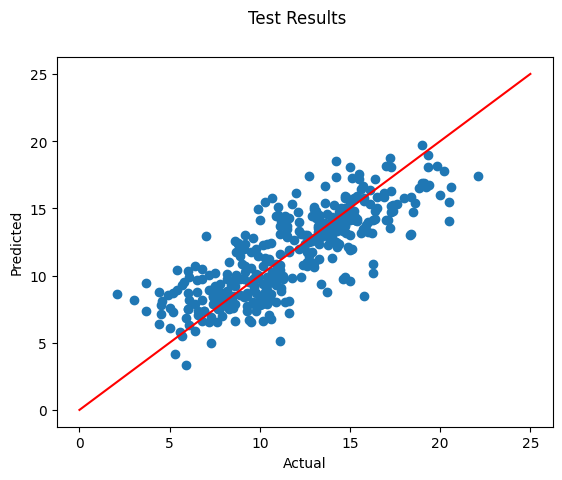

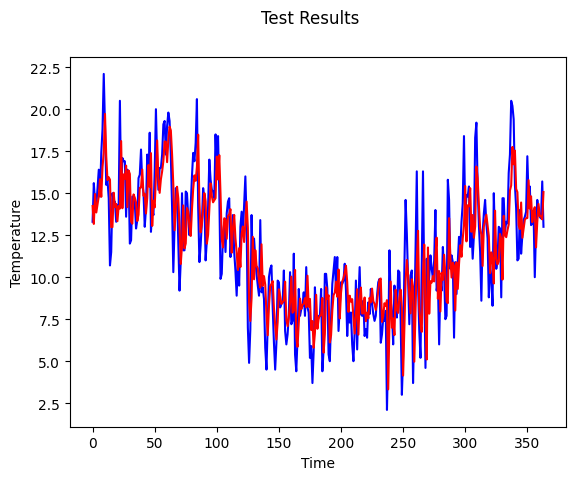

In [18]:
# show scatterplots of actual vs. predicted for train and test
# make a prediction
pred = model.predict(X_test)# the pred

# calculate MSE for the baseline model
from sklearn.metrics import mean_absolute_error
print('MAE: ', mean_absolute_error(y_test, pred))

actual = y_test # the actual
plt.scatter(x=actual, y=pred)
x = np.linspace(0,25) # 45 degree line from 0 to 25 (axes are the same)
plt.plot(x, x, color='red')
plt.suptitle('Test Results')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()
# looks pretty good!

# show timeseries plot on the train and validation data
plt.plot(np.arange(X_test.shape[0]), y_test, color='blue') # actual data
plt.plot(np.arange(X_test.shape[0]), pred, color='red') # predicted data
plt.suptitle('Test Results')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.show()

## On your own: add the learning curve and the train results!

# LSTM one layer model
Literally, just grab the code above and change SimpleRNN to LSTM and boom! you have a more sophisticated model.

In [19]:
# now let's build a model

# since this is a univariate problem, n_features will be 1 (we also defined this before)
n_features = X.shape[2] # 1 green dot = 1 feature
n_steps = X.shape[1] # these are time steps = there are 10!

# define model
model = Sequential()
model.add(LSTM(30, input_shape=(n_steps,n_features), activation='relu')) # 30 red dots = hidden size of 30
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse',metrics=['mae'])
model.summary()

es = EarlyStopping(monitor='val_loss', mode='min',
                   patience=10,
                   verbose=1,
                   restore_best_weights=True)

# fit model (uses early stopping)
model.fit(X_train, y_train,
          epochs=500,
          batch_size=5,
          validation_split=0.2, # val is a random 20% of the data since we set shuffle = True
          verbose=1,
          callbacks=[es],
          shuffle=True)

C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30)             │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,871 (15.12 KB)

 Trainable params: 3,871 (15.12 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 51:28 6s/step - loss: 196.6994 - mae: 13.5530

 10/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 122.7698 - mae: 10.5271  

 19/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 95.6634 - mae: 9.1686  

 28/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 74.3060 - mae: 7.6756

 38/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 57.0366 - mae: 6.2712

 48/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 47.9508 - mae: 5.5873

 57/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 41.9533 - mae: 5.1131

 67/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 36.5985 - mae: 4.6427

 78/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 32.7907 - mae: 4.3554

 88/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 29.7516 - mae: 4.0899

 98/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 27.4930 - mae: 3.9071

107/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 25.7243 - mae: 3.7428

116/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 24.4415 - mae: 3.6356

126/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 23.0335 - mae: 3.5094

135/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 22.0903 - mae: 3.4424

145/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 20.8760 - mae: 3.3217

156/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 19.8483 - mae: 3.2324

168/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 18.8950 - mae: 3.1409

181/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 17.9977 - mae: 3.0557

195/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 17.2732 - mae: 2.9905

209/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 16.6781 - mae: 2.9447

224/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 15.9355 - mae: 2.8729

239/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 15.3621 - mae: 2.8243

254/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 14.8256 - mae: 2.7736

267/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 14.3585 - mae: 2.7221

281/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 13.9523 - mae: 2.6858

295/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 13.5228 - mae: 2.6412

308/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 13.2875 - mae: 2.6251

323/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13.0424 - mae: 2.6075

335/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12.7459 - mae: 2.5776

347/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12.5433 - mae: 2.5643

359/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12.3098 - mae: 2.5410

371/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12.1604 - mae: 2.5310

385/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11.8822 - mae: 2.5012

398/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11.7290 - mae: 2.4901

413/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 11.4862 - mae: 2.4668

427/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 11.3276 - mae: 2.4495

443/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 11.2296 - mae: 2.4393

461/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 10.9917 - mae: 2.4142

476/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 10.8082 - mae: 2.3955

489/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 10.6851 - mae: 2.3844

501/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 10.5392 - mae: 2.3676

513/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 10.4303 - mae: 2.3573

523/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 10.3687 - mae: 2.3547

524/524 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 10.3507 - mae: 2.3518 - val_loss: 5.4463 - val_mae: 1.8400


Epoch 2/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 1:07 129ms/step - loss: 16.1431 - mae: 3.7573

 10/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 8.2267 - mae: 2.3821     

 18/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 6.7142 - mae: 2.0717

 26/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 7.2518 - mae: 2.1776

 35/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 7.2804 - mae: 2.1776

 45/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.4280 - mae: 2.2060

 55/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.5982 - mae: 2.2114

 65/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.5643 - mae: 2.2083

 75/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.5363 - mae: 2.2145

 85/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.4202 - mae: 2.2143

 96/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.4319 - mae: 2.2195

107/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.2391 - mae: 2.1762

119/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.2299 - mae: 2.1663

129/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.2392 - mae: 2.1689

138/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.1888 - mae: 2.1586

148/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.1245 - mae: 2.1506

157/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0311 - mae: 2.1346

167/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9775 - mae: 2.1184

178/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9565 - mae: 2.1071

187/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9550 - mae: 2.1014

195/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9465 - mae: 2.0983

203/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.9202 - mae: 2.0954

211/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.9319 - mae: 2.0937

217/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.9317 - mae: 2.0986

227/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.8178 - mae: 2.0753

236/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.7898 - mae: 2.0744

247/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.8485 - mae: 2.0801

258/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.7481 - mae: 2.0608

269/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6756 - mae: 2.0466

279/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6575 - mae: 2.0468

289/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6105 - mae: 2.0343

299/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5738 - mae: 2.0308

309/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6149 - mae: 2.0370

319/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6672 - mae: 2.0443

328/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6515 - mae: 2.0405

338/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6255 - mae: 2.0383

348/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5961 - mae: 2.0362

357/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5615 - mae: 2.0322

367/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5913 - mae: 2.0364

377/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5569 - mae: 2.0298

387/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5084 - mae: 2.0214

399/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5261 - mae: 2.0241

409/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5141 - mae: 2.0243

422/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5000 - mae: 2.0174

434/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4864 - mae: 2.0158

446/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5420 - mae: 2.0166

458/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5221 - mae: 2.0135

470/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4773 - mae: 2.0052

484/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4130 - mae: 1.9960

495/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4179 - mae: 1.9960

505/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3764 - mae: 1.9897

516/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3577 - mae: 1.9864

524/524 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 6.3839 - mae: 1.9923 - val_loss: 5.3895 - val_mae: 1.8313


Epoch 3/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 1:02 120ms/step - loss: 16.3258 - mae: 3.7899

 11/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.3311 - mae: 2.1869     

 20/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.5435 - mae: 2.0357

 29/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.9895 - mae: 2.1396

 38/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.9296 - mae: 2.1193

 47/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.3105 - mae: 2.1784

 55/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.3944 - mae: 2.1722

 66/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.4157 - mae: 2.1778

 74/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.3967 - mae: 2.1785

 83/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.3693 - mae: 2.1947

 90/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.1958 - mae: 2.1684

 97/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.2864 - mae: 2.1884

106/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.1725 - mae: 2.1583

115/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.1852 - mae: 2.1513

125/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.1674 - mae: 2.1448

134/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.2417 - mae: 2.1622

143/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.0677 - mae: 2.1296

151/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.0326 - mae: 2.1273

160/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.9132 - mae: 2.1085

170/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.9151 - mae: 2.0965

179/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.8290 - mae: 2.0790

189/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.8819 - mae: 2.0820

199/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.8354 - mae: 2.0727

209/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.8653 - mae: 2.0761

220/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.8434 - mae: 2.0747

231/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6857 - mae: 2.0486

241/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.7114 - mae: 2.0459

249/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.7395 - mae: 2.0549

259/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6378 - mae: 2.0360

269/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5656 - mae: 2.0211

278/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5624 - mae: 2.0235

286/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5312 - mae: 2.0163

294/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4795 - mae: 2.0075

300/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4746 - mae: 2.0088

307/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5207 - mae: 2.0157

314/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5382 - mae: 2.0183

320/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5854 - mae: 2.0236

328/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5563 - mae: 2.0180

337/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5374 - mae: 2.0166

347/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5184 - mae: 2.0171

356/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.4586 - mae: 2.0081

366/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.4953 - mae: 2.0142

377/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.4674 - mae: 2.0088

388/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.4436 - mae: 2.0042

398/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.4454 - mae: 2.0040

408/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.4225 - mae: 2.0018

417/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.4386 - mae: 2.0018

427/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.4041 - mae: 1.9953

436/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.4101 - mae: 1.9974

445/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.4628 - mae: 1.9968

453/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.4614 - mae: 1.9985

460/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.4324 - mae: 1.9924

468/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3924 - mae: 1.9846

478/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3637 - mae: 1.9810

487/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3543 - mae: 1.9803

497/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3304 - mae: 1.9753

505/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3004 - mae: 1.9711

515/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2874 - mae: 1.9685

524/524 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 6.3090 - mae: 1.9739 - val_loss: 5.3739 - val_mae: 1.8321


Epoch 4/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 12:00 1s/step - loss: 16.4130 - mae: 3.8070

 12/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.1681 - mae: 2.1678   

 22/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.6951 - mae: 2.0775

 33/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9445 - mae: 2.1281

 43/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9921 - mae: 2.1260

 52/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.2790 - mae: 2.1437

 60/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.4144 - mae: 2.1682

 69/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.3134 - mae: 2.1603

 77/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.3415 - mae: 2.1720

 85/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.2573 - mae: 2.1718

 94/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.3115 - mae: 2.1813

104/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.1338 - mae: 2.1513

114/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.1696 - mae: 2.1421

124/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.1435 - mae: 2.1369

133/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.1276 - mae: 2.1387

142/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.0385 - mae: 2.1212

151/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.9912 - mae: 2.1163

158/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.8763 - mae: 2.0988

167/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.8513 - mae: 2.0878

175/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.7856 - mae: 2.0701

183/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.8006 - mae: 2.0712

192/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.8144 - mae: 2.0676

201/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.7677 - mae: 2.0556

209/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.8234 - mae: 2.0657

217/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.7781 - mae: 2.0625

225/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6977 - mae: 2.0445

232/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6237 - mae: 2.0340

239/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6853 - mae: 2.0407

245/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6685 - mae: 2.0380

253/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6574 - mae: 2.0374

263/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5564 - mae: 2.0165

272/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4934 - mae: 2.0058

282/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5088 - mae: 2.0096

291/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4533 - mae: 1.9999

299/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4239 - mae: 1.9960

306/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4433 - mae: 2.0009

310/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4799 - mae: 2.0043

319/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5277 - mae: 2.0115

326/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5303 - mae: 2.0098

334/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4820 - mae: 2.0036

340/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4854 - mae: 2.0075

348/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4652 - mae: 2.0048

355/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4236 - mae: 1.9979

363/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4570 - mae: 2.0045

371/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.4719 - mae: 2.0066

378/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.4342 - mae: 2.0010

387/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3837 - mae: 1.9915

395/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.4208 - mae: 1.9975

404/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.4039 - mae: 1.9934

413/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3603 - mae: 1.9894

423/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3928 - mae: 1.9906

432/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3604 - mae: 1.9849

440/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.4004 - mae: 1.9886

449/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.4322 - mae: 1.9889

459/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.4076 - mae: 1.9851

469/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3593 - mae: 1.9764

480/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3196 - mae: 1.9708

491/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3221 - mae: 1.9717

502/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2857 - mae: 1.9660

513/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2770 - mae: 1.9649

524/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2801 - mae: 1.9662

524/524 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 6.2801 - mae: 1.9662 - val_loss: 5.3631 - val_mae: 1.8321


Epoch 5/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 1:07 129ms/step - loss: 16.3097 - mae: 3.7978

  9/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 7.8379 - mae: 2.2985     

 16/524 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 6.7965 - mae: 2.0670

 23/524 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 6.7885 - mae: 2.1015

 31/524 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 6.8027 - mae: 2.1035

 38/524 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 6.8383 - mae: 2.1029

 46/524 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 7.1016 - mae: 2.1395

 53/524 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 7.2374 - mae: 2.1399

 63/524 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 7.4160 - mae: 2.1707

 70/524 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 7.3301 - mae: 2.1593

 78/524 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 7.3512 - mae: 2.1762

 84/524 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 7.2626 - mae: 2.1728

 93/524 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 7.3061 - mae: 2.1799

102/524 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 7.0617 - mae: 2.1428

111/524 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 7.2099 - mae: 2.1427

122/524 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 7.1274 - mae: 2.1309

131/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.0762 - mae: 2.1287

138/524 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 7.0156 - mae: 2.1163

148/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.9546 - mae: 2.1087

155/524 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 6.9390 - mae: 2.1089

162/524 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 6.9089 - mae: 2.0973

170/524 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 6.8520 - mae: 2.0833

178/524 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 6.7811 - mae: 2.0676

187/524 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 6.7852 - mae: 2.0635

196/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.7819 - mae: 2.0599

204/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.7263 - mae: 2.0511

213/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.7817 - mae: 2.0591

223/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.7053 - mae: 2.0453

233/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6155 - mae: 2.0302

242/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6250 - mae: 2.0274

250/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6541 - mae: 2.0357

259/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5619 - mae: 2.0184

268/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5030 - mae: 2.0063

278/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4891 - mae: 2.0069

285/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4504 - mae: 1.9978

294/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4096 - mae: 1.9912

303/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4327 - mae: 1.9986

313/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4759 - mae: 2.0024

321/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5145 - mae: 2.0076

330/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4767 - mae: 1.9995

339/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4627 - mae: 2.0007

346/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4438 - mae: 1.9986

355/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3986 - mae: 1.9920

365/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.4394 - mae: 2.0000

374/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.4330 - mae: 1.9988

385/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3616 - mae: 1.9856

396/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.4016 - mae: 1.9920

408/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3610 - mae: 1.9863

419/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3896 - mae: 1.9882

430/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3296 - mae: 1.9780

441/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3684 - mae: 1.9810

452/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.4088 - mae: 1.9844

464/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3583 - mae: 1.9743

477/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3103 - mae: 1.9673

490/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3042 - mae: 1.9673

501/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2608 - mae: 1.9599

512/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2519 - mae: 1.9586

523/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2638 - mae: 1.9622

524/524 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 6.2539 - mae: 1.9600 - val_loss: 5.3553 - val_mae: 1.8319


Epoch 6/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - loss: 16.3386 - mae: 3.8035

 14/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 7.0087 - mae: 2.1354   

 26/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.9810 - mae: 2.1226

 39/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.8565 - mae: 2.1058

 51/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.2156 - mae: 2.1339

 65/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.3638 - mae: 2.1548

 77/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.2887 - mae: 2.1583

 87/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.1196 - mae: 2.1425

 93/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.2825 - mae: 2.1712

102/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.0452 - mae: 2.1358

111/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.1926 - mae: 2.1360

118/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0676 - mae: 2.1222

126/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0597 - mae: 2.1195

134/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.1418 - mae: 2.1362

143/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9756 - mae: 2.1040

153/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9544 - mae: 2.1073

160/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8332 - mae: 2.0882

169/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7938 - mae: 2.0741

177/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7462 - mae: 2.0607

187/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7687 - mae: 2.0580

197/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7411 - mae: 2.0498

203/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.7215 - mae: 2.0465

213/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.7615 - mae: 2.0526

223/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6830 - mae: 2.0386

233/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5934 - mae: 2.0236

242/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6048 - mae: 2.0214

252/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6258 - mae: 2.0286

260/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5367 - mae: 2.0116

267/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4900 - mae: 2.0016

273/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4606 - mae: 1.9957

282/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4601 - mae: 1.9984

292/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4135 - mae: 1.9897

303/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4126 - mae: 1.9931

312/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4413 - mae: 1.9944

323/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5067 - mae: 2.0032

333/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4468 - mae: 1.9939

344/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4271 - mae: 1.9943

355/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3802 - mae: 1.9869

366/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.4167 - mae: 1.9939

376/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3933 - mae: 1.9891

385/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3458 - mae: 1.9807

395/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3768 - mae: 1.9861

404/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3598 - mae: 1.9822

412/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3251 - mae: 1.9793

418/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3716 - mae: 1.9829

426/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3328 - mae: 1.9762

433/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3203 - mae: 1.9749

438/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3722 - mae: 1.9812

447/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3760 - mae: 1.9755

453/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3833 - mae: 1.9784

462/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3333 - mae: 1.9678

472/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3067 - mae: 1.9644

479/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2817 - mae: 1.9609

489/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2864 - mae: 1.9624

498/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2634 - mae: 1.9577

506/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2385 - mae: 1.9545

515/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2139 - mae: 1.9501

524/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2374 - mae: 1.9556

524/524 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 6.2374 - mae: 1.9556 - val_loss: 5.3535 - val_mae: 1.8320


Epoch 7/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 25s 50ms/step - loss: 16.2446 - mae: 3.7974

 12/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0138 - mae: 2.1336   

 23/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.6979 - mae: 2.0798

 34/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8122 - mae: 2.1034

 44/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0280 - mae: 2.1233

 53/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.1596 - mae: 2.1201

 63/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.3327 - mae: 2.1517

 71/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.2608 - mae: 2.1432

 79/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.2725 - mae: 2.1585

 88/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.1413 - mae: 2.1444

 97/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.1865 - mae: 2.1600

104/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.0809 - mae: 2.1359

112/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.1690 - mae: 2.1332

119/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.0082 - mae: 2.1104

128/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.0002 - mae: 2.1064

137/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.0080 - mae: 2.1103

146/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.9236 - mae: 2.0953

155/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.8876 - mae: 2.0930

165/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.7996 - mae: 2.0748

173/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.7694 - mae: 2.0636

184/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.7224 - mae: 2.0533

194/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.7524 - mae: 2.0501

201/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.7036 - mae: 2.0380

211/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.7223 - mae: 2.0414

220/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.7251 - mae: 2.0449

230/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5672 - mae: 2.0179

241/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5963 - mae: 2.0169

249/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6306 - mae: 2.0273

258/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5234 - mae: 2.0068

267/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4714 - mae: 1.9972

277/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4574 - mae: 1.9974

286/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4220 - mae: 1.9900

296/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3708 - mae: 1.9820

307/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4120 - mae: 1.9894

318/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4778 - mae: 1.9988

330/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4443 - mae: 1.9905

342/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4123 - mae: 1.9897

354/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3789 - mae: 1.9860

367/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4067 - mae: 1.9912

378/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3768 - mae: 1.9861

390/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3581 - mae: 1.9808

400/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3388 - mae: 1.9778

409/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3347 - mae: 1.9795

417/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3444 - mae: 1.9776

427/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3112 - mae: 1.9712

435/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3191 - mae: 1.9729

443/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3829 - mae: 1.9756

452/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3749 - mae: 1.9752

460/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3405 - mae: 1.9682

468/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2994 - mae: 1.9608

476/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2825 - mae: 1.9596

486/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2567 - mae: 1.9557

496/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2472 - mae: 1.9540

503/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2247 - mae: 1.9516

513/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2201 - mae: 1.9508

522/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2315 - mae: 1.9534

524/524 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 6.2246 - mae: 1.9520 - val_loss: 5.3451 - val_mae: 1.8311


Epoch 8/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step - loss: 16.1770 - mae: 3.7905

 12/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9891 - mae: 2.1284   

 23/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.6710 - mae: 2.0750

 34/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7941 - mae: 2.1009

 47/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 7.0408 - mae: 2.1275

 59/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 7.2538 - mae: 2.1434

 71/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.2392 - mae: 2.1381

 83/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.2362 - mae: 2.1569

 94/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.2334 - mae: 2.1592

105/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.0326 - mae: 2.1252

117/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.0380 - mae: 2.1123

129/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.9957 - mae: 2.1063

140/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.9297 - mae: 2.0943

151/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.9136 - mae: 2.0943

161/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7853 - mae: 2.0775

172/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7569 - mae: 2.0602

181/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7068 - mae: 2.0520

189/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7652 - mae: 2.0549

197/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7166 - mae: 2.0438

206/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7596 - mae: 2.0480

215/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7078 - mae: 2.0425

224/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6329 - mae: 2.0278

234/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5443 - mae: 2.0135

243/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5786 - mae: 2.0169

252/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5995 - mae: 2.0230

261/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4909 - mae: 2.0015

268/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4551 - mae: 1.9953

278/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4435 - mae: 1.9963

287/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3968 - mae: 1.9857

296/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3618 - mae: 1.9809

306/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3701 - mae: 1.9846

315/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4164 - mae: 1.9899

322/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4877 - mae: 1.9987

330/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4360 - mae: 1.9894

339/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4196 - mae: 1.9900

348/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3975 - mae: 1.9887

357/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3584 - mae: 1.9846

366/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3913 - mae: 1.9884

376/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3678 - mae: 1.9837

387/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3199 - mae: 1.9752

399/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3295 - mae: 1.9767

410/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3201 - mae: 1.9769

420/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3386 - mae: 1.9764

430/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2854 - mae: 1.9670

440/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3268 - mae: 1.9710

449/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3590 - mae: 1.9711

460/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3295 - mae: 1.9663

471/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2880 - mae: 1.9590

483/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2471 - mae: 1.9540

492/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2494 - mae: 1.9543

498/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2408 - mae: 1.9525

504/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2076 - mae: 1.9485

511/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2199 - mae: 1.9502

517/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1870 - mae: 1.9442

524/524 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 6.2150 - mae: 1.9504 - val_loss: 5.3441 - val_mae: 1.8308


Epoch 9/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 40s 78ms/step - loss: 16.2196 - mae: 3.7966

 10/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.7379 - mae: 2.2687   

 21/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.6940 - mae: 2.0580

 32/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7255 - mae: 2.0777

 43/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8292 - mae: 2.0972

 54/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.1281 - mae: 2.1160

 65/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.3027 - mae: 2.1388

 75/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.2533 - mae: 2.1415

 87/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0680 - mae: 2.1276

 96/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.1846 - mae: 2.1551

105/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0218 - mae: 2.1220

114/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0743 - mae: 2.1168

124/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0500 - mae: 2.1116

131/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9951 - mae: 2.1055

139/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9385 - mae: 2.0954

148/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8744 - mae: 2.0851

154/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8877 - mae: 2.0911

161/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.7694 - mae: 2.0732

168/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.7774 - mae: 2.0688

178/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.7159 - mae: 2.0510

185/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.7557 - mae: 2.0523

195/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.7162 - mae: 2.0425

206/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.7454 - mae: 2.0445

217/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6846 - mae: 2.0395

227/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5713 - mae: 2.0162

238/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5956 - mae: 2.0200

246/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5738 - mae: 2.0171

255/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5276 - mae: 2.0090

264/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4631 - mae: 1.9970

274/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4386 - mae: 1.9925

284/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4079 - mae: 1.9880

296/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3488 - mae: 1.9783

308/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3839 - mae: 1.9847

319/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4469 - mae: 1.9932

329/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4225 - mae: 1.9858

339/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4068 - mae: 1.9875

350/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3855 - mae: 1.9870

360/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3468 - mae: 1.9813

370/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3962 - mae: 1.9880

379/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3427 - mae: 1.9791

387/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3072 - mae: 1.9726

398/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3238 - mae: 1.9747

407/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3038 - mae: 1.9724

416/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3194 - mae: 1.9726

427/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2860 - mae: 1.9663

436/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2903 - mae: 1.9680

445/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3446 - mae: 1.9681

453/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3420 - mae: 1.9692

461/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3040 - mae: 1.9613

471/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2748 - mae: 1.9562

479/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2480 - mae: 1.9530

484/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2254 - mae: 1.9497

491/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2426 - mae: 1.9526

498/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2278 - mae: 1.9500

505/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.1933 - mae: 1.9455

512/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2013 - mae: 1.9468

520/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2000 - mae: 1.9462

524/524 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 6.2028 - mae: 1.9479 - val_loss: 5.3416 - val_mae: 1.8304


Epoch 10/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 13:45 2s/step - loss: 16.2091 - mae: 3.7960

 13/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.5879 - mae: 2.0531   

 24/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7607 - mae: 2.0868

 33/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8358 - mae: 2.1052

 43/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8230 - mae: 2.0955

 51/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.1120 - mae: 2.1113

 60/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.2387 - mae: 2.1357

 66/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.2506 - mae: 2.1346

 75/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.2405 - mae: 2.1377

 83/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.2096 - mae: 2.1492

 90/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.0554 - mae: 2.1268

 98/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.1021 - mae: 2.1402

106/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.0577 - mae: 2.1245

115/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.0301 - mae: 2.1095

124/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.0393 - mae: 2.1082

134/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.0736 - mae: 2.1182

142/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.9219 - mae: 2.0891

152/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.8673 - mae: 2.0829

161/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.7579 - mae: 2.0701

169/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.7407 - mae: 2.0605

177/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.6892 - mae: 2.0475

187/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.7178 - mae: 2.0456

196/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.7189 - mae: 2.0426

204/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6600 - mae: 2.0329

212/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6921 - mae: 2.0363

221/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6717 - mae: 2.0345

230/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5342 - mae: 2.0109

240/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5849 - mae: 2.0151

249/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6020 - mae: 2.0218

258/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4914 - mae: 2.0008

266/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4283 - mae: 1.9912

275/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4180 - mae: 1.9895

284/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3988 - mae: 1.9861

295/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3430 - mae: 1.9766

306/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3471 - mae: 1.9802

316/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4194 - mae: 1.9895

325/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4619 - mae: 1.9938

335/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3928 - mae: 1.9831

346/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3760 - mae: 1.9836

355/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3296 - mae: 1.9771

365/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3734 - mae: 1.9849

373/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3720 - mae: 1.9835

383/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2979 - mae: 1.9704

392/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3232 - mae: 1.9750

397/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3225 - mae: 1.9743

404/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3099 - mae: 1.9714

412/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2741 - mae: 1.9683

419/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3229 - mae: 1.9724

427/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2751 - mae: 1.9640

437/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2975 - mae: 1.9674

445/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3346 - mae: 1.9659

454/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3222 - mae: 1.9652

464/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2905 - mae: 1.9580

473/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2508 - mae: 1.9520

481/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2347 - mae: 1.9504

491/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2343 - mae: 1.9507

501/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2005 - mae: 1.9459

512/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.1933 - mae: 1.9450

522/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2003 - mae: 1.9474

524/524 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 6.1934 - mae: 1.9460 - val_loss: 5.3368 - val_mae: 1.8314


Epoch 11/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 11:55 1s/step - loss: 16.4485 - mae: 3.8270

 10/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.7686 - mae: 2.2742   

 19/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.3981 - mae: 1.9846

 29/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.8042 - mae: 2.0944

 38/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.7611 - mae: 2.0860

 48/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.9572 - mae: 2.1124

 56/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.3694 - mae: 2.1556

 66/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.2365 - mae: 2.1343

 76/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.1941 - mae: 2.1352

 84/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.1532 - mae: 2.1426

 93/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.2181 - mae: 2.1533

104/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.0389 - mae: 2.1255

111/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.1287 - mae: 2.1200

122/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.0293 - mae: 2.1029

129/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.9465 - mae: 2.0924

139/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.9009 - mae: 2.0852

149/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.8418 - mae: 2.0749

160/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.7542 - mae: 2.0677

167/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.7347 - mae: 2.0578

175/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.6644 - mae: 2.0415

184/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6685 - mae: 2.0418

193/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6716 - mae: 2.0343

203/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6509 - mae: 2.0296

213/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6894 - mae: 2.0359

223/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6090 - mae: 2.0219

234/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5013 - mae: 2.0041

244/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5422 - mae: 2.0098

253/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5380 - mae: 2.0105

264/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4352 - mae: 1.9918

276/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4155 - mae: 1.9895

287/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3569 - mae: 1.9781

298/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3102 - mae: 1.9715

309/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3557 - mae: 1.9782

320/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4382 - mae: 1.9902

331/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3918 - mae: 1.9813

340/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3754 - mae: 1.9824

348/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3575 - mae: 1.9810

356/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3073 - mae: 1.9741

365/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3568 - mae: 1.9814

374/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3507 - mae: 1.9802

383/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2818 - mae: 1.9669

393/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3196 - mae: 1.9730

404/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2933 - mae: 1.9678

416/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2922 - mae: 1.9666

427/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2582 - mae: 1.9602

438/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3050 - mae: 1.9664

448/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3194 - mae: 1.9621

458/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2989 - mae: 1.9593

470/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2592 - mae: 1.9521

480/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2171 - mae: 1.9461

490/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2287 - mae: 1.9489

501/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1857 - mae: 1.9424

511/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1857 - mae: 1.9428

520/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1771 - mae: 1.9409

524/524 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 6.1789 - mae: 1.9425 - val_loss: 5.3314 - val_mae: 1.8318


Epoch 12/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 15:24 2s/step - loss: 16.3426 - mae: 3.8159

 14/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.8640 - mae: 2.0963   

 26/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.9432 - mae: 2.1071

 38/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.7448 - mae: 2.0822

 49/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 7.1227 - mae: 2.1252

 61/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 7.1766 - mae: 2.1270

 72/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 7.0988 - mae: 2.1110

 80/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.1802 - mae: 2.1420

 88/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0707 - mae: 2.1274

 96/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.1435 - mae: 2.1470

106/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0252 - mae: 2.1192

116/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0182 - mae: 2.1071

126/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9666 - mae: 2.0970

137/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9363 - mae: 2.0943

147/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8566 - mae: 2.0804

160/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7508 - mae: 2.0687

173/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7075 - mae: 2.0519

186/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7011 - mae: 2.0426

200/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6712 - mae: 2.0329

213/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6816 - mae: 2.0362

226/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5559 - mae: 2.0139

238/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5584 - mae: 2.0138

251/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5435 - mae: 2.0135

264/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4270 - mae: 1.9919

277/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4029 - mae: 1.9894

288/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3514 - mae: 1.9781

299/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2952 - mae: 1.9706

310/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3570 - mae: 1.9794

321/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4229 - mae: 1.9894

333/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3741 - mae: 1.9803

346/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3500 - mae: 1.9795

360/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3105 - mae: 1.9752

374/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3418 - mae: 1.9793

388/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2956 - mae: 1.9694

402/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2828 - mae: 1.9666

417/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2820 - mae: 1.9655

432/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2344 - mae: 1.9568

445/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.3088 - mae: 1.9611

459/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2839 - mae: 1.9572

473/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2275 - mae: 1.9474

487/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2107 - mae: 1.9457

500/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1829 - mae: 1.9420

514/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1609 - mae: 1.9396

524/524 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 6.1699 - mae: 1.9413 - val_loss: 5.3268 - val_mae: 1.8316


Epoch 13/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 19:06 2s/step - loss: 16.3611 - mae: 3.8194

  9/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 7.7658 - mae: 2.2681   

 18/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 6.3304 - mae: 1.9769

 28/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.7633 - mae: 2.0842

 38/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.7405 - mae: 2.0809

 46/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.9441 - mae: 2.1062

 55/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.0940 - mae: 2.1140

 64/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.3012 - mae: 2.1424

 74/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.1548 - mae: 2.1221

 82/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.1372 - mae: 2.1361

 91/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.9940 - mae: 2.1199

100/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.9909 - mae: 2.1240

108/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.9720 - mae: 2.1116

116/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.0001 - mae: 2.1042

126/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.9489 - mae: 2.0941

136/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.9492 - mae: 2.0965

145/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.8328 - mae: 2.0729

153/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.8487 - mae: 2.0823

162/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.7936 - mae: 2.0683

168/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.7246 - mae: 2.0593

176/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.6474 - mae: 2.0404

185/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.7019 - mae: 2.0432

194/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.6735 - mae: 2.0368

204/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6171 - mae: 2.0264

212/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6483 - mae: 2.0301

222/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6177 - mae: 2.0273

232/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4860 - mae: 2.0040

243/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5204 - mae: 2.0068

254/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5045 - mae: 2.0072

264/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4191 - mae: 1.9909

275/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3861 - mae: 1.9858

287/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3412 - mae: 1.9771

298/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.2942 - mae: 1.9703

309/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3402 - mae: 1.9771

320/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4217 - mae: 1.9889

330/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3806 - mae: 1.9801

339/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3617 - mae: 1.9800

350/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3407 - mae: 1.9797

360/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3018 - mae: 1.9737

368/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3292 - mae: 1.9767

378/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3133 - mae: 1.9741

389/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2785 - mae: 1.9660

398/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2789 - mae: 1.9662

408/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2604 - mae: 1.9647

419/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2874 - mae: 1.9661

428/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2328 - mae: 1.9567

438/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2859 - mae: 1.9635

449/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3000 - mae: 1.9597

459/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2771 - mae: 1.9568

470/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2417 - mae: 1.9503

479/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2063 - mae: 1.9457

489/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2097 - mae: 1.9468

499/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.1812 - mae: 1.9422

510/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.1546 - mae: 1.9393

522/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1679 - mae: 1.9419

524/524 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 6.1608 - mae: 1.9404 - val_loss: 5.3197 - val_mae: 1.8316


Epoch 14/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 15:48 2s/step - loss: 16.2150 - mae: 3.8024

 12/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9129 - mae: 2.1099   

 21/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.6390 - mae: 2.0443

 31/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.6724 - mae: 2.0703

 42/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8540 - mae: 2.0933

 52/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0373 - mae: 2.0988

 62/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.2196 - mae: 2.1405

 73/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.1281 - mae: 2.1163

 83/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.1361 - mae: 2.1385

 94/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.1479 - mae: 2.1418

103/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9562 - mae: 2.1187

114/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0076 - mae: 2.1029

123/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9492 - mae: 2.0885

133/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9463 - mae: 2.0934

143/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8495 - mae: 2.0726

153/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8293 - mae: 2.0771

158/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7138 - mae: 2.0589

168/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7109 - mae: 2.0551

179/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6272 - mae: 2.0352

187/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6654 - mae: 2.0359

197/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6450 - mae: 2.0288

205/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6972 - mae: 2.0351

213/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6624 - mae: 2.0311

223/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5772 - mae: 2.0160

230/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4856 - mae: 2.0018

240/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5360 - mae: 2.0066

248/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5570 - mae: 2.0134

259/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4440 - mae: 1.9936

268/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3840 - mae: 1.9832

278/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3776 - mae: 1.9851

289/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3185 - mae: 1.9714

300/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2788 - mae: 1.9681

311/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3497 - mae: 1.9767

319/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3896 - mae: 1.9837

328/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3819 - mae: 1.9792

339/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3499 - mae: 1.9772

350/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3289 - mae: 1.9770

361/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3060 - mae: 1.9732

373/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3264 - mae: 1.9748

384/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2448 - mae: 1.9601

394/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2860 - mae: 1.9670

405/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2570 - mae: 1.9613

417/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2620 - mae: 1.9609

429/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2119 - mae: 1.9518

440/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2561 - mae: 1.9567

451/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2978 - mae: 1.9585

463/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2377 - mae: 1.9473

476/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2112 - mae: 1.9441

490/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2035 - mae: 1.9435

503/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1551 - mae: 1.9371

517/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1301 - mae: 1.9318

524/524 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 6.1533 - mae: 1.9371 - val_loss: 5.3147 - val_mae: 1.8301


Epoch 15/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step - loss: 16.3562 - mae: 3.8189

 15/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.5600 - mae: 2.0470   

 25/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.8882 - mae: 2.0878

 35/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9162 - mae: 2.1046

 45/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9596 - mae: 2.1109

 54/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0921 - mae: 2.1097

 64/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.2735 - mae: 2.1409

 75/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.1407 - mae: 2.1250

 81/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0945 - mae: 2.1346

 91/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9657 - mae: 2.1163

102/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9294 - mae: 2.1122

108/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.9543 - mae: 2.1090

116/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.9704 - mae: 2.0993

119/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.8946 - mae: 2.0879

128/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.8816 - mae: 2.0815

137/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.8879 - mae: 2.0843

145/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.8037 - mae: 2.0667

153/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.8175 - mae: 2.0759

154/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.8003 - mae: 2.0731

162/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.7655 - mae: 2.0624

169/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.6750 - mae: 2.0490

179/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.6168 - mae: 2.0345

190/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.6907 - mae: 2.0408

198/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.6370 - mae: 2.0281

207/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6861 - mae: 2.0343

214/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6431 - mae: 2.0303

224/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5476 - mae: 2.0113

232/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4662 - mae: 1.9997

238/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5266 - mae: 2.0078

247/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5474 - mae: 2.0120

256/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4610 - mae: 1.9970

264/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3982 - mae: 1.9870

271/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3323 - mae: 1.9751

280/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3496 - mae: 1.9807

290/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3052 - mae: 1.9713

298/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.2739 - mae: 1.9663

309/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3208 - mae: 1.9735

319/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3817 - mae: 1.9829

329/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3589 - mae: 1.9751

338/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3519 - mae: 1.9770

346/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3216 - mae: 1.9742

354/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.2889 - mae: 1.9705

363/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3101 - mae: 1.9739

374/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3156 - mae: 1.9743

380/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2748 - mae: 1.9667

388/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2721 - mae: 1.9648

396/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2817 - mae: 1.9662

401/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2615 - mae: 1.9625

412/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2221 - mae: 1.9585

421/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2487 - mae: 1.9585

428/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2171 - mae: 1.9533

438/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2708 - mae: 1.9606

449/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2837 - mae: 1.9561

457/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2767 - mae: 1.9558

464/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2422 - mae: 1.9488

473/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2048 - mae: 1.9430

481/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.1868 - mae: 1.9409

489/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.1946 - mae: 1.9426

492/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.1805 - mae: 1.9400

501/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.1540 - mae: 1.9365

504/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.1405 - mae: 1.9348

514/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.1368 - mae: 1.9346

518/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.1275 - mae: 1.9322

524/524 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 6.1462 - mae: 1.9362 - val_loss: 5.2956 - val_mae: 1.8281


Epoch 16/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 1:32 177ms/step - loss: 15.9669 - mae: 3.7674

 12/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8468 - mae: 2.0926     

 21/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.5829 - mae: 2.0324

 29/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.7234 - mae: 2.0721

 39/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.7149 - mae: 2.0746

 45/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.8920 - mae: 2.0994

 54/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.0223 - mae: 2.0983

 62/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.1603 - mae: 2.1304

 71/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.0744 - mae: 2.1096

 80/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.1064 - mae: 2.1298

 88/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.9992 - mae: 2.1151

 96/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.0827 - mae: 2.1369

107/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.9520 - mae: 2.1055

116/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.9562 - mae: 2.0956

125/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.9322 - mae: 2.0873

134/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.9804 - mae: 2.0995

144/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.8236 - mae: 2.0691

153/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.8053 - mae: 2.0729

164/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.7164 - mae: 2.0556

173/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.6547 - mae: 2.0418

178/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.6266 - mae: 2.0348

179/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.6047 - mae: 2.0318

189/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.6688 - mae: 2.0359

196/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.6480 - mae: 2.0300

205/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6769 - mae: 2.0320

212/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6225 - mae: 2.0238

220/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6190 - mae: 2.0246

228/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4846 - mae: 2.0006

234/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4533 - mae: 1.9960

242/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4901 - mae: 1.9991

247/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5394 - mae: 2.0098

257/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4477 - mae: 1.9939

260/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.4230 - mae: 1.9903

268/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.3688 - mae: 1.9807

273/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.3528 - mae: 1.9771

282/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.3504 - mae: 1.9794

287/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.3135 - mae: 1.9714

295/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.2834 - mae: 1.9664

305/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.2919 - mae: 1.9711

315/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.3277 - mae: 1.9746

323/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.3994 - mae: 1.9836

334/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.3292 - mae: 1.9713

342/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.3182 - mae: 1.9723

352/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.3014 - mae: 1.9723

358/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.2593 - mae: 1.9653

366/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.3088 - mae: 1.9719

375/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.2999 - mae: 1.9708

381/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.2534 - mae: 1.9613

391/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.2676 - mae: 1.9625

401/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.2527 - mae: 1.9596

409/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.2393 - mae: 1.9602

417/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.2481 - mae: 1.9579

425/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.2238 - mae: 1.9527

435/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.2241 - mae: 1.9537

443/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.2907 - mae: 1.9567

453/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2725 - mae: 1.9544

462/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2256 - mae: 1.9449

472/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2089 - mae: 1.9425

478/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.1943 - mae: 1.9406

486/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.1728 - mae: 1.9373

489/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.1898 - mae: 1.9406

498/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.1675 - mae: 1.9366

505/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.1351 - mae: 1.9330

516/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.1160 - mae: 1.9290

524/524 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 6.1421 - mae: 1.9346 - val_loss: 5.3082 - val_mae: 1.8295


Epoch 17/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 2:14 258ms/step - loss: 16.2205 - mae: 3.8070

 10/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 7.6917 - mae: 2.2506     

 18/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 6.2734 - mae: 1.9575

 28/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.7501 - mae: 2.0734

 29/524 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 6.7849 - mae: 2.0771

 38/524 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 6.7156 - mae: 2.0710

 47/524 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 6.9919 - mae: 2.1121

 56/524 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 7.2897 - mae: 2.1426

 65/524 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 7.1687 - mae: 2.1209

 72/524 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 7.0163 - mae: 2.0997

 82/524 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 7.0766 - mae: 2.1284

 91/524 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 6.9358 - mae: 2.1118

 97/524 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 7.0535 - mae: 2.1366

105/524 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 6.9235 - mae: 2.1051

110/524 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 7.0808 - mae: 2.1131

120/524 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 6.8729 - mae: 2.0854

123/524 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 6.9108 - mae: 2.0834

132/524 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 6.9130 - mae: 2.0869

140/524 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 6.8040 - mae: 2.0677

150/524 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 6.7810 - mae: 2.0664

160/524 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 6.6873 - mae: 2.0573

166/524 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 6.7053 - mae: 2.0553

175/524 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 6.5993 - mae: 2.0321

183/524 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 6.6167 - mae: 2.0345

192/524 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 6.6375 - mae: 2.0309

201/524 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 6.5919 - mae: 2.0179

208/524 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 6.6772 - mae: 2.0343

215/524 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 6.6016 - mae: 2.0231

223/524 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 6.5475 - mae: 2.0118

230/524 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 6.4573 - mae: 1.9978

240/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.5081 - mae: 2.0029

248/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.5317 - mae: 2.0100

258/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.4201 - mae: 1.9893

269/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.3499 - mae: 1.9781

278/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.3559 - mae: 1.9823

280/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.3350 - mae: 1.9780

290/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.2904 - mae: 1.9685

293/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.2891 - mae: 1.9682

301/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.2581 - mae: 1.9652

312/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.3205 - mae: 1.9731

321/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.3763 - mae: 1.9810

331/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.3386 - mae: 1.9724

340/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.3199 - mae: 1.9730

349/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.2939 - mae: 1.9702

361/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.2791 - mae: 1.9683

365/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.3029 - mae: 1.9716

372/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.3058 - mae: 1.9712

378/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.2766 - mae: 1.9663

388/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.2535 - mae: 1.9604

390/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.2571 - mae: 1.9606

400/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.2342 - mae: 1.9570

404/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.2400 - mae: 1.9576

413/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.1946 - mae: 1.9534

417/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.2379 - mae: 1.9565

426/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.2096 - mae: 1.9510

436/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.2105 - mae: 1.9523

444/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.2787 - mae: 1.9554

454/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.2536 - mae: 1.9516

465/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.2225 - mae: 1.9450

472/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.1996 - mae: 1.9413

482/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.1635 - mae: 1.9358

493/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.1599 - mae: 1.9360

504/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.1251 - mae: 1.9313

516/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.1055 - mae: 1.9273

524/524 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 6.1325 - mae: 1.9330 - val_loss: 5.2949 - val_mae: 1.8274


Epoch 18/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 8:54 1s/step - loss: 15.8744 - mae: 3.7603

 11/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0083 - mae: 2.1017  

 19/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.2645 - mae: 1.9451

 29/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.7566 - mae: 2.0701

 40/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7060 - mae: 2.0654

 49/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.0467 - mae: 2.1107

 56/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.2595 - mae: 2.1377

 60/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.1230 - mae: 2.1178

 70/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.0650 - mae: 2.1054

 79/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.0934 - mae: 2.1277

 88/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.9784 - mae: 2.1134

 98/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.9881 - mae: 2.1235

105/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.9094 - mae: 2.1026

113/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.9731 - mae: 2.0971

121/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.8523 - mae: 2.0821

130/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.9013 - mae: 2.0858

138/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.8093 - mae: 2.0679

147/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.7766 - mae: 2.0654

154/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.7670 - mae: 2.0677

163/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.7260 - mae: 2.0574

171/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.6507 - mae: 2.0411

176/524 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 6.5898 - mae: 2.0309

186/524 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 6.6362 - mae: 2.0310

195/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.6138 - mae: 2.0246

205/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.6545 - mae: 2.0294

215/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5895 - mae: 2.0209

221/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5785 - mae: 2.0188

231/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4542 - mae: 1.9980

238/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4972 - mae: 2.0030

248/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5212 - mae: 2.0081

258/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4100 - mae: 1.9877

267/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3583 - mae: 1.9797

274/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3546 - mae: 1.9798

278/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.3455 - mae: 1.9807

288/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.2978 - mae: 1.9691

298/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.2460 - mae: 1.9613

310/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3021 - mae: 1.9701

319/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3523 - mae: 1.9774

329/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3301 - mae: 1.9695

339/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3096 - mae: 1.9699

347/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3018 - mae: 1.9707

357/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.2459 - mae: 1.9637

368/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2799 - mae: 1.9665

378/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2649 - mae: 1.9641

389/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2314 - mae: 1.9562

400/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2224 - mae: 1.9551

411/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2012 - mae: 1.9539

423/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2161 - mae: 1.9527

435/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2032 - mae: 1.9507

447/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2486 - mae: 1.9497

459/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2319 - mae: 1.9474

471/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.1933 - mae: 1.9400

483/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.1517 - mae: 1.9347

495/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.1497 - mae: 1.9339

507/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.1206 - mae: 1.9307

519/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.1070 - mae: 1.9282

524/524 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 6.1232 - mae: 1.9316 - val_loss: 5.2845 - val_mae: 1.8266


Epoch 19/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 32s 62ms/step - loss: 15.5807 - mae: 3.7213

 13/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.4214 - mae: 1.9966   

 24/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.6527 - mae: 2.0561

 36/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.8301 - mae: 2.0842

 46/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8492 - mae: 2.0870

 57/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.1753 - mae: 2.1327

 68/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9872 - mae: 2.1007

 79/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0711 - mae: 2.1248

 90/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9052 - mae: 2.1036

100/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9043 - mae: 2.1099

112/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.0061 - mae: 2.1021

124/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9040 - mae: 2.0832

135/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9195 - mae: 2.0893

146/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7657 - mae: 2.0621

158/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6610 - mae: 2.0499

169/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6343 - mae: 2.0411

180/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5703 - mae: 2.0268

191/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6328 - mae: 2.0305

203/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5696 - mae: 2.0165

215/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5804 - mae: 2.0187

227/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4653 - mae: 1.9970

238/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4884 - mae: 2.0010

248/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5124 - mae: 2.0062

252/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4841 - mae: 2.0024

261/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3768 - mae: 1.9821

268/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3413 - mae: 1.9768

278/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3362 - mae: 1.9790

288/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2881 - mae: 1.9673

296/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2474 - mae: 1.9608

305/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2612 - mae: 1.9663

311/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3048 - mae: 1.9694

319/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3416 - mae: 1.9755

330/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3217 - mae: 1.9689

340/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2957 - mae: 1.9684

348/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2794 - mae: 1.9669

355/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2322 - mae: 1.9591

365/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2815 - mae: 1.9674

375/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2669 - mae: 1.9646

386/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2070 - mae: 1.9523

397/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2299 - mae: 1.9562

407/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2054 - mae: 1.9531

418/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2311 - mae: 1.9546

428/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1773 - mae: 1.9457

439/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2205 - mae: 1.9506

450/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2512 - mae: 1.9493

461/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2077 - mae: 1.9426

472/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1812 - mae: 1.9381

482/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1451 - mae: 1.9326

492/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1471 - mae: 1.9333

500/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1270 - mae: 1.9305

510/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1087 - mae: 1.9289

521/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1156 - mae: 1.9290

524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 6.1163 - mae: 1.9299 - val_loss: 5.2860 - val_mae: 1.8258


Epoch 20/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 55s 106ms/step - loss: 15.4765 - mae: 3.7073

 11/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9885 - mae: 2.0945    

 20/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.1596 - mae: 1.9409

 28/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.6899 - mae: 2.0585

 38/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.6563 - mae: 2.0574

 49/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0164 - mae: 2.1054

 59/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0760 - mae: 2.1150

 70/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0289 - mae: 2.0998

 81/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0159 - mae: 2.1216

 93/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0706 - mae: 2.1297

104/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9062 - mae: 2.1041

115/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8868 - mae: 2.0847

126/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8500 - mae: 2.0761

138/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7867 - mae: 2.0642

151/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7583 - mae: 2.0630

163/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7052 - mae: 2.0543

175/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5693 - mae: 2.0278

186/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6170 - mae: 2.0281

198/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5855 - mae: 2.0197

209/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6215 - mae: 2.0248

220/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5768 - mae: 2.0187

231/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4387 - mae: 1.9958

242/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4529 - mae: 1.9939

252/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4746 - mae: 2.0014

263/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3569 - mae: 1.9794

274/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3364 - mae: 1.9773

284/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3026 - mae: 1.9716

295/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2430 - mae: 1.9607

305/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2519 - mae: 1.9653

315/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2868 - mae: 1.9684

326/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3429 - mae: 1.9727

336/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3143 - mae: 1.9692

345/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2742 - mae: 1.9663

356/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2168 - mae: 1.9579

366/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2678 - mae: 1.9647

377/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2389 - mae: 1.9590

387/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2028 - mae: 1.9521

398/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2133 - mae: 1.9533

406/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2013 - mae: 1.9522

416/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2110 - mae: 1.9516

428/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1714 - mae: 1.9446

439/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2144 - mae: 1.9493

448/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2416 - mae: 1.9477

459/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2171 - mae: 1.9445

471/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1765 - mae: 1.9368

482/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1384 - mae: 1.9317

493/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1346 - mae: 1.9317

504/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1008 - mae: 1.9273

515/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0870 - mae: 1.9244

524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 6.1091 - mae: 1.9289 - val_loss: 5.2840 - val_mae: 1.8257


Epoch 21/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step - loss: 15.3285 - mae: 3.6852

 14/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.6611 - mae: 2.0451   

 27/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.7505 - mae: 2.0628

 42/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.7559 - mae: 2.0705

 57/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.1667 - mae: 2.1295

 71/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.0041 - mae: 2.0994

 84/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.9947 - mae: 2.1179

 99/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.9171 - mae: 2.1119

114/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.9110 - mae: 2.0863

127/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.8068 - mae: 2.0691

142/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.7819 - mae: 2.0624

155/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.7143 - mae: 2.0581

168/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.6399 - mae: 2.0440

179/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.5512 - mae: 2.0240

190/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.6276 - mae: 2.0296

201/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.5505 - mae: 2.0107

211/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.5691 - mae: 2.0145

222/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.5317 - mae: 2.0115

233/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.4253 - mae: 1.9918

244/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.4491 - mae: 1.9946

255/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.4036 - mae: 1.9874

265/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.3244 - mae: 1.9744

276/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.3221 - mae: 1.9753

287/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2609 - mae: 1.9628

298/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2105 - mae: 1.9544

309/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2595 - mae: 1.9624

319/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.3160 - mae: 1.9707

330/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2966 - mae: 1.9640

340/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2700 - mae: 1.9634

347/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2666 - mae: 1.9637

358/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2005 - mae: 1.9536

368/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2443 - mae: 1.9594

377/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2224 - mae: 1.9551

385/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1882 - mae: 1.9485

395/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2067 - mae: 1.9523

407/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1801 - mae: 1.9484

419/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2074 - mae: 1.9505

430/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1439 - mae: 1.9398

441/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1864 - mae: 1.9435

452/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2268 - mae: 1.9463

463/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1735 - mae: 1.9359

476/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1499 - mae: 1.9330

489/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1417 - mae: 1.9320

503/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0945 - mae: 1.9256

514/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0860 - mae: 1.9244

524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 6.0987 - mae: 1.9265 - val_loss: 5.2942 - val_mae: 1.8259


Epoch 22/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 21:05 2s/step - loss: 15.2568 - mae: 3.6695

 13/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.4426 - mae: 1.9929   

 26/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.8642 - mae: 2.0801

 39/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.6951 - mae: 2.0658

 53/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.0125 - mae: 2.0940

 67/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.9970 - mae: 2.0985

 81/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.0041 - mae: 2.1220

 96/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.0095 - mae: 2.1296

111/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.9849 - mae: 2.0996

123/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.8397 - mae: 2.0734

135/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.8833 - mae: 2.0860

148/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.7081 - mae: 2.0555

160/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.6378 - mae: 2.0506

170/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.6369 - mae: 2.0425

182/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.5495 - mae: 2.0256

195/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.5730 - mae: 2.0193

208/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.6225 - mae: 2.0273

218/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.5284 - mae: 2.0150

227/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.4338 - mae: 1.9949

239/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.4518 - mae: 1.9968

250/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.4617 - mae: 2.0007

260/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.3598 - mae: 1.9823

271/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.2601 - mae: 1.9650

282/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.2842 - mae: 1.9709

292/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2343 - mae: 1.9601

302/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2205 - mae: 1.9605

313/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2717 - mae: 1.9662

324/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.3463 - mae: 1.9760

335/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2616 - mae: 1.9614

347/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2545 - mae: 1.9634

358/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1893 - mae: 1.9532

369/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2554 - mae: 1.9617

380/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2008 - mae: 1.9524

391/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2037 - mae: 1.9515

402/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1868 - mae: 1.9485

412/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1509 - mae: 1.9453

423/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1757 - mae: 1.9460

434/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1531 - mae: 1.9420

444/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2264 - mae: 1.9465

455/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2075 - mae: 1.9436

467/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1661 - mae: 1.9351

479/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1289 - mae: 1.9299

490/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1346 - mae: 1.9315

501/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0927 - mae: 1.9252

512/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0882 - mae: 1.9250

523/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1005 - mae: 1.9281

524/524 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 6.0906 - mae: 1.9259 - val_loss: 5.2947 - val_mae: 1.8253


Epoch 23/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 32s 62ms/step - loss: 15.2612 - mae: 3.6706

 12/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8435 - mae: 2.0790   

 24/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.6639 - mae: 2.0564

 36/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8376 - mae: 2.0874

 48/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8459 - mae: 2.0876

 59/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0796 - mae: 2.1161

 69/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9729 - mae: 2.0955

 79/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0570 - mae: 2.1250

 87/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8890 - mae: 2.1016

 98/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9386 - mae: 2.1182

107/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8766 - mae: 2.0970

117/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8489 - mae: 2.0796

128/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7974 - mae: 2.0694

140/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7457 - mae: 2.0594

153/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7461 - mae: 2.0659

164/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6593 - mae: 2.0483

175/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5487 - mae: 2.0264

187/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5774 - mae: 2.0232

199/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5507 - mae: 2.0151

210/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5728 - mae: 2.0178

222/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5129 - mae: 2.0108

233/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4086 - mae: 1.9916

242/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4229 - mae: 1.9909

252/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4417 - mae: 1.9974

263/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3235 - mae: 1.9753

273/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2839 - mae: 1.9683

284/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2676 - mae: 1.9670

294/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2063 - mae: 1.9550

304/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2150 - mae: 1.9604

313/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2647 - mae: 1.9650

324/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3398 - mae: 1.9748

335/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2539 - mae: 1.9598

344/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2387 - mae: 1.9600

353/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2075 - mae: 1.9553

360/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1980 - mae: 1.9546

371/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2341 - mae: 1.9588

382/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1805 - mae: 1.9482

393/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2022 - mae: 1.9516

402/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1789 - mae: 1.9473

412/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1431 - mae: 1.9441

422/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1605 - mae: 1.9429

433/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1390 - mae: 1.9404

445/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2087 - mae: 1.9430

456/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1949 - mae: 1.9417

468/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1471 - mae: 1.9318

480/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1132 - mae: 1.9272

491/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1159 - mae: 1.9284

503/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0790 - mae: 1.9241

515/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0582 - mae: 1.9200

524/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0821 - mae: 1.9248

524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 6.0821 - mae: 1.9248 - val_loss: 5.2795 - val_mae: 1.8231


Epoch 24/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 17:46 2s/step - loss: 14.7956 - mae: 3.5904

 13/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.3873 - mae: 1.9796   

 26/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.8193 - mae: 2.0724

 39/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.6427 - mae: 2.0559

 52/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.9451 - mae: 2.0824

 64/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.0945 - mae: 2.1116

 74/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.9626 - mae: 2.0927

 85/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.9346 - mae: 2.1103

 97/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.9519 - mae: 2.1222

107/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8451 - mae: 2.0912

117/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8224 - mae: 2.0750

125/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8389 - mae: 2.0747

136/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8253 - mae: 2.0758

146/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7124 - mae: 2.0555

156/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6710 - mae: 2.0534

166/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6369 - mae: 2.0453

175/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5314 - mae: 2.0234

185/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5944 - mae: 2.0260

196/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5685 - mae: 2.0184

207/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5942 - mae: 2.0210

218/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5132 - mae: 2.0121

228/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4096 - mae: 1.9908

238/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4402 - mae: 1.9954

248/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4626 - mae: 2.0002

258/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3510 - mae: 1.9795

267/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2947 - mae: 1.9713

278/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2831 - mae: 1.9721

287/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2335 - mae: 1.9606

295/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1992 - mae: 1.9542

303/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2093 - mae: 1.9589

310/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2349 - mae: 1.9601

320/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3071 - mae: 1.9701

331/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2643 - mae: 1.9608

340/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2432 - mae: 1.9606

350/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2246 - mae: 1.9584

356/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1713 - mae: 1.9494

366/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2284 - mae: 1.9581

374/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2239 - mae: 1.9574

382/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1720 - mae: 1.9467

391/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1874 - mae: 1.9489

398/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1709 - mae: 1.9462

407/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1564 - mae: 1.9449

414/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1274 - mae: 1.9411

423/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1593 - mae: 1.9434

432/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1215 - mae: 1.9369

440/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1623 - mae: 1.9409

451/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2055 - mae: 1.9428

462/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1490 - mae: 1.9326

470/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1473 - mae: 1.9315

480/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1057 - mae: 1.9256

490/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1187 - mae: 1.9289

500/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0819 - mae: 1.9232

505/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0639 - mae: 1.9214

516/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0458 - mae: 1.9176

524/524 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 6.0745 - mae: 1.9234 - val_loss: 5.2872 - val_mae: 1.8249


Epoch 25/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 13:44 2s/step - loss: 14.9091 - mae: 3.6096

 10/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 7.6301 - mae: 2.2346   

 19/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 6.2080 - mae: 1.9375

 28/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.6840 - mae: 2.0580

 37/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.7097 - mae: 2.0676

 43/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 6.7262 - mae: 2.0719

 52/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.9789 - mae: 2.0883

 60/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.0670 - mae: 2.1084

 71/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.9665 - mae: 2.0947

 82/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.9772 - mae: 2.1148

 91/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.8423 - mae: 2.0990

100/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.8309 - mae: 2.1024

110/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.9858 - mae: 2.0981

119/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.8021 - mae: 2.0744

127/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.7965 - mae: 2.0711

136/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.8474 - mae: 2.0811

144/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.7677 - mae: 2.0638

154/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.7361 - mae: 2.0653

164/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.6560 - mae: 2.0488

175/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.5427 - mae: 2.0259

185/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5904 - mae: 2.0263

195/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5547 - mae: 2.0171

206/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5712 - mae: 2.0180

216/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5060 - mae: 2.0107

225/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4377 - mae: 1.9974

235/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3542 - mae: 1.9843

245/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4246 - mae: 1.9950

256/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3684 - mae: 1.9842

265/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.2887 - mae: 1.9722

273/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.2699 - mae: 1.9677

285/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.2368 - mae: 1.9627

296/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.1869 - mae: 1.9534

306/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.1963 - mae: 1.9580

317/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.2648 - mae: 1.9673

327/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.2918 - mae: 1.9674

336/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.2590 - mae: 1.9621

347/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2250 - mae: 1.9589

357/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.1706 - mae: 1.9515

367/524 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2229 - mae: 1.9590

377/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1863 - mae: 1.9514

389/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1599 - mae: 1.9456

400/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1504 - mae: 1.9446

411/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1309 - mae: 1.9436

422/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1406 - mae: 1.9410

434/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1250 - mae: 1.9389

446/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1864 - mae: 1.9406

458/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1675 - mae: 1.9375

470/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1352 - mae: 1.9310

481/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0957 - mae: 1.9260

492/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0908 - mae: 1.9252

503/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0601 - mae: 1.9220

513/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0578 - mae: 1.9220

523/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0732 - mae: 1.9250

524/524 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 6.0632 - mae: 1.9228 - val_loss: 5.2684 - val_mae: 1.8228


Epoch 26/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 16:58 2s/step - loss: 14.5743 - mae: 3.5484

 12/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7196 - mae: 2.0514   

 22/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.3369 - mae: 1.9907

 33/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.6895 - mae: 2.0667

 43/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.6548 - mae: 2.0578

 53/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9321 - mae: 2.0779

 63/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0440 - mae: 2.1012

 72/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8755 - mae: 2.0754

 82/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9498 - mae: 2.1075

 90/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8202 - mae: 2.0909

 98/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8684 - mae: 2.1053

109/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7669 - mae: 2.0773

118/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8041 - mae: 2.0722

127/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7597 - mae: 2.0626

136/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8124 - mae: 2.0730

144/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7310 - mae: 2.0553

153/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7116 - mae: 2.0595

164/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6250 - mae: 2.0413

172/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5545 - mae: 2.0252

182/524 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5092 - mae: 2.0179

193/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5129 - mae: 2.0099

204/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4840 - mae: 2.0050

215/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5074 - mae: 2.0096

226/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4170 - mae: 1.9930

236/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3603 - mae: 1.9850

246/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4049 - mae: 1.9914

257/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3512 - mae: 1.9806

268/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2703 - mae: 1.9683

279/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2537 - mae: 1.9680

290/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1996 - mae: 1.9563

300/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1653 - mae: 1.9514

309/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2125 - mae: 1.9577

318/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2745 - mae: 1.9678

325/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2995 - mae: 1.9689

335/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2243 - mae: 1.9560

346/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2057 - mae: 1.9543

355/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1566 - mae: 1.9465

364/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1916 - mae: 1.9540

374/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2037 - mae: 1.9552

385/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1431 - mae: 1.9433

393/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1713 - mae: 1.9481

404/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1481 - mae: 1.9438

414/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1055 - mae: 1.9391

424/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1295 - mae: 1.9399

433/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1088 - mae: 1.9368

443/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1911 - mae: 1.9416

452/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1794 - mae: 1.9403

459/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1535 - mae: 1.9353

470/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1260 - mae: 1.9296

479/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0912 - mae: 1.9250

488/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0858 - mae: 1.9244

497/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0692 - mae: 1.9218

504/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0431 - mae: 1.9192

513/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0474 - mae: 1.9206

523/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0639 - mae: 1.9238

524/524 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 6.0539 - mae: 1.9215 - val_loss: 5.2746 - val_mae: 1.8229


Epoch 27/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 12:11 1s/step - loss: 14.1277 - mae: 3.4471

 13/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.3300 - mae: 1.9657   

 25/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7521 - mae: 2.0541

 37/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.6388 - mae: 2.0524

 49/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.9379 - mae: 2.0924

 60/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.9883 - mae: 2.0950

 71/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8968 - mae: 2.0836

 82/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9231 - mae: 2.1057

 93/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9639 - mae: 2.1147

105/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7717 - mae: 2.0806

117/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7786 - mae: 2.0667

128/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7308 - mae: 2.0574

139/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7161 - mae: 2.0540

151/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6877 - mae: 2.0522

161/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5707 - mae: 2.0379

173/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5379 - mae: 2.0244

185/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5518 - mae: 2.0183

197/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4977 - mae: 2.0060

209/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5352 - mae: 2.0120

221/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4784 - mae: 2.0051

233/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3598 - mae: 1.9844

245/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3919 - mae: 1.9889

256/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3380 - mae: 1.9786

267/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2587 - mae: 1.9665

278/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2485 - mae: 1.9676

290/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1809 - mae: 1.9532

300/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1474 - mae: 1.9484

312/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2082 - mae: 1.9566

324/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2942 - mae: 1.9682

336/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2298 - mae: 1.9568

347/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1959 - mae: 1.9529

358/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1359 - mae: 1.9435

370/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2005 - mae: 1.9539

381/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1351 - mae: 1.9425

392/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1416 - mae: 1.9436

403/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1262 - mae: 1.9404

414/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0871 - mae: 1.9360

425/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1067 - mae: 1.9355

436/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1012 - mae: 1.9354

447/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1520 - mae: 1.9345

458/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1410 - mae: 1.9328

469/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1013 - mae: 1.9249

481/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0720 - mae: 1.9218

491/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0732 - mae: 1.9221

501/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0408 - mae: 1.9177

511/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0420 - mae: 1.9187

523/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0492 - mae: 1.9210

524/524 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 6.0391 - mae: 1.9187 - val_loss: 5.2765 - val_mae: 1.8232


Epoch 28/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 18:07 2s/step - loss: 14.3244 - mae: 3.4947

 13/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.3314 - mae: 1.9663   

 24/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.6036 - mae: 2.0438

 35/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7839 - mae: 2.0753

 46/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7793 - mae: 2.0744

 58/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.0698 - mae: 2.1117

 68/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8743 - mae: 2.0823

 78/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9849 - mae: 2.1065

 90/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8098 - mae: 2.0894

101/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8041 - mae: 2.0959

112/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8992 - mae: 2.0848

121/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7524 - mae: 2.0652

131/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7766 - mae: 2.0662

141/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7209 - mae: 2.0532

152/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6856 - mae: 2.0523

163/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6448 - mae: 2.0439

173/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5485 - mae: 2.0261

184/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5019 - mae: 2.0159

195/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5194 - mae: 2.0096

206/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5398 - mae: 2.0113

217/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4886 - mae: 2.0081

227/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3898 - mae: 1.9880

238/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4096 - mae: 1.9908

249/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4327 - mae: 1.9964

260/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3141 - mae: 1.9754

272/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2292 - mae: 1.9619

284/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2320 - mae: 1.9620

295/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1682 - mae: 1.9499

306/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1728 - mae: 1.9529

316/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2366 - mae: 1.9612

328/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2513 - mae: 1.9584

340/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2060 - mae: 1.9542

352/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1757 - mae: 1.9493

363/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1837 - mae: 1.9517

374/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1870 - mae: 1.9516

386/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1179 - mae: 1.9385

398/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1292 - mae: 1.9405

409/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1190 - mae: 1.9414

421/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1205 - mae: 1.9374

434/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0956 - mae: 1.9337

445/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1607 - mae: 1.9356

457/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1513 - mae: 1.9345

468/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1009 - mae: 1.9243

480/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0667 - mae: 1.9199

492/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0659 - mae: 1.9204

504/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0260 - mae: 1.9154

515/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0117 - mae: 1.9129

524/524 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 6.0378 - mae: 1.9180 - val_loss: 5.2694 - val_mae: 1.8216


Epoch 29/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 31s 60ms/step - loss: 13.7548 - mae: 3.3440

 12/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.6655 - mae: 2.0353   

 24/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.5838 - mae: 2.0371

 36/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7434 - mae: 2.0700

 48/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.7337 - mae: 2.0712

 60/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.9684 - mae: 2.0929

 72/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.8127 - mae: 2.0683

 84/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.8788 - mae: 2.1027

 96/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.8889 - mae: 2.1082

108/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.7588 - mae: 2.0765

120/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.7147 - mae: 2.0589

131/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.7390 - mae: 2.0588

143/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.6911 - mae: 2.0463

155/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.6315 - mae: 2.0444

167/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.5453 - mae: 2.0262

178/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.4791 - mae: 2.0117

190/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.5330 - mae: 2.0138

202/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.4545 - mae: 1.9965

214/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.4888 - mae: 2.0055

226/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.3788 - mae: 1.9855

238/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.3799 - mae: 1.9853

249/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.4031 - mae: 1.9910

260/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.2837 - mae: 1.9694

272/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.2008 - mae: 1.9563

284/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.2050 - mae: 1.9568

296/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.1363 - mae: 1.9439

307/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1838 - mae: 1.9530

318/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2397 - mae: 1.9608

330/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2138 - mae: 1.9515

342/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1758 - mae: 1.9476

353/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1430 - mae: 1.9427

364/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1549 - mae: 1.9461

375/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1609 - mae: 1.9465

386/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0982 - mae: 1.9342

398/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1094 - mae: 1.9361

410/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0932 - mae: 1.9358

422/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0936 - mae: 1.9317

434/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0774 - mae: 1.9296

446/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1405 - mae: 1.9313

458/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1222 - mae: 1.9284

470/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0920 - mae: 1.9221

482/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0426 - mae: 1.9153

494/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0372 - mae: 1.9151

506/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0205 - mae: 1.9134

518/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.9989 - mae: 1.9099

524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 6.0218 - mae: 1.9145 - val_loss: 5.2657 - val_mae: 1.8197


Epoch 30/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step - loss: 13.7137 - mae: 3.3334

 13/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.2423 - mae: 1.9400   

 25/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7196 - mae: 2.0428

 36/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7357 - mae: 2.0688

 47/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8062 - mae: 2.0831

 59/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9410 - mae: 2.0926

 71/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8564 - mae: 2.0779

 83/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9008 - mae: 2.1050

 95/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.9005 - mae: 2.1067

107/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.7641 - mae: 2.0745

119/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.7078 - mae: 2.0558

131/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.7325 - mae: 2.0564

143/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.6851 - mae: 2.0442

155/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.6253 - mae: 2.0423

167/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.5381 - mae: 2.0239

179/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.4486 - mae: 2.0064

191/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.5056 - mae: 2.0082

203/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.4496 - mae: 1.9957

215/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.4592 - mae: 1.9990

227/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.3531 - mae: 1.9802

239/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.3702 - mae: 1.9826

251/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.3642 - mae: 1.9838

264/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.2465 - mae: 1.9628

276/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.2353 - mae: 1.9626

288/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.1750 - mae: 1.9501

300/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1211 - mae: 1.9423

312/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1842 - mae: 1.9504

324/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2695 - mae: 1.9620

336/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2071 - mae: 1.9513

348/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1640 - mae: 1.9453

360/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1257 - mae: 1.9403

372/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1669 - mae: 1.9464

384/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0874 - mae: 1.9311

396/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1227 - mae: 1.9375

407/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0884 - mae: 1.9325

418/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1163 - mae: 1.9344

430/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0547 - mae: 1.9244

441/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0990 - mae: 1.9282

452/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1373 - mae: 1.9305

463/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0870 - mae: 1.9206

474/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0739 - mae: 1.9194

485/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0259 - mae: 1.9117

495/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0361 - mae: 1.9132

506/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0137 - mae: 1.9111

517/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.9872 - mae: 1.9064

524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 6.0136 - mae: 1.9122 - val_loss: 5.2714 - val_mae: 1.8224


Epoch 31/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 51s 99ms/step - loss: 13.7324 - mae: 3.3523

 12/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.5915 - mae: 2.0094   

 22/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.2577 - mae: 1.9661

 32/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.5618 - mae: 2.0320

 43/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.5885 - mae: 2.0460

 54/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8934 - mae: 2.0733

 66/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8861 - mae: 2.0799

 78/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9331 - mae: 2.0961

 90/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7578 - mae: 2.0781

102/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7039 - mae: 2.0721

113/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8035 - mae: 2.0633

124/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7766 - mae: 2.0591

134/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8308 - mae: 2.0719

146/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6497 - mae: 2.0398

158/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5563 - mae: 2.0300

170/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5518 - mae: 2.0225

182/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4600 - mae: 2.0060

194/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4921 - mae: 2.0023

206/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5042 - mae: 2.0019

218/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4461 - mae: 1.9984

230/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3320 - mae: 1.9768

242/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3523 - mae: 1.9775

254/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3360 - mae: 1.9780

266/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2251 - mae: 1.9588

278/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.2266 - mae: 1.9614

289/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1644 - mae: 1.9468

300/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1215 - mae: 1.9419

311/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1909 - mae: 1.9499

322/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2577 - mae: 1.9596

333/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1889 - mae: 1.9472

344/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1633 - mae: 1.9441

356/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1052 - mae: 1.9352

368/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1582 - mae: 1.9434

379/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1274 - mae: 1.9380

389/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1037 - mae: 1.9328

400/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0903 - mae: 1.9311

411/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0718 - mae: 1.9302

421/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0929 - mae: 1.9297

431/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0551 - mae: 1.9238

442/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0852 - mae: 1.9251

452/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1326 - mae: 1.9295

461/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0933 - mae: 1.9218

472/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0676 - mae: 1.9175

482/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0330 - mae: 1.9125

492/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0366 - mae: 1.9133

502/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0076 - mae: 1.9100

510/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9975 - mae: 1.9094

517/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9805 - mae: 1.9052

524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 6.0066 - mae: 1.9110 - val_loss: 5.2713 - val_mae: 1.8240


Epoch 32/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 30s 59ms/step - loss: 13.5802 - mae: 3.2855

 13/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.2211 - mae: 1.9277   

 24/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.5231 - mae: 2.0221

 35/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7016 - mae: 2.0581

 45/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7155 - mae: 2.0666

 55/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8523 - mae: 2.0718

 66/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8593 - mae: 2.0758

 78/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9111 - mae: 2.0927

 90/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7386 - mae: 2.0745

102/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6937 - mae: 2.0722

114/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7822 - mae: 2.0628

126/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7258 - mae: 2.0523

139/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6839 - mae: 2.0456

152/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.6409 - mae: 2.0419

164/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.5710 - mae: 2.0281

177/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.4456 - mae: 2.0067

189/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.5044 - mae: 2.0069

201/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.4485 - mae: 1.9922

214/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.4842 - mae: 2.0030

225/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.3821 - mae: 1.9841

236/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.3184 - mae: 1.9755

247/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.3971 - mae: 1.9873

258/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.2880 - mae: 1.9668

269/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.2118 - mae: 1.9561

280/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.2015 - mae: 1.9561

292/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.1535 - mae: 1.9453

303/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1459 - mae: 1.9469

313/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1883 - mae: 1.9502

323/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2461 - mae: 1.9577

332/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1870 - mae: 1.9465

343/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1501 - mae: 1.9413

355/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1054 - mae: 1.9340

365/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1627 - mae: 1.9455

369/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1679 - mae: 1.9446

379/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1210 - mae: 1.9367

388/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1078 - mae: 1.9336

398/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0923 - mae: 1.9311

409/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0810 - mae: 1.9318

418/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1063 - mae: 1.9318

428/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0544 - mae: 1.9234

439/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0994 - mae: 1.9278

450/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1264 - mae: 1.9266

460/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0980 - mae: 1.9225

469/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0646 - mae: 1.9156

480/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0331 - mae: 1.9115

491/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0361 - mae: 1.9126

502/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0021 - mae: 1.9082

512/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9984 - mae: 1.9085

522/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0081 - mae: 1.9109

524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 6.0018 - mae: 1.9096 - val_loss: 5.2733 - val_mae: 1.8243


Epoch 33/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 38s 73ms/step - loss: 13.6322 - mae: 3.3246

 12/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.5321 - mae: 1.9861   

 22/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.1912 - mae: 1.9504

 31/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.4351 - mae: 2.0073

 42/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.5684 - mae: 2.0356

 53/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7990 - mae: 2.0528

 63/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8923 - mae: 2.0730

 73/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8066 - mae: 2.0629

 83/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8358 - mae: 2.0875

 92/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7705 - mae: 2.0756

103/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.6875 - mae: 2.0742

112/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8279 - mae: 2.0713

122/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7583 - mae: 2.0548

130/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7193 - mae: 2.0508

140/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.6270 - mae: 2.0341

150/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.6065 - mae: 2.0336

159/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5192 - mae: 2.0239

170/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5193 - mae: 2.0170

181/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4189 - mae: 2.0009

192/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4629 - mae: 1.9990

201/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4285 - mae: 1.9880

212/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4538 - mae: 1.9956

222/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4229 - mae: 1.9921

231/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3222 - mae: 1.9752

242/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3373 - mae: 1.9746

253/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3372 - mae: 1.9768

261/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2506 - mae: 1.9609

271/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1770 - mae: 1.9495

281/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2115 - mae: 1.9568

293/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1467 - mae: 1.9437

304/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1436 - mae: 1.9468

315/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1726 - mae: 1.9484

326/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2294 - mae: 1.9528

337/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1872 - mae: 1.9470

348/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1532 - mae: 1.9426

360/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1135 - mae: 1.9373

372/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1558 - mae: 1.9438

383/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0826 - mae: 1.9301

394/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1071 - mae: 1.9347

406/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0753 - mae: 1.9301

419/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1045 - mae: 1.9327

432/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0448 - mae: 1.9230

444/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1319 - mae: 1.9295

457/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1118 - mae: 1.9258

470/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0703 - mae: 1.9181

483/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0222 - mae: 1.9120

498/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0157 - mae: 1.9103

512/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9921 - mae: 1.9089

524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 5.9969 - mae: 1.9101 - val_loss: 5.2750 - val_mae: 1.8250


Epoch 34/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 42s 81ms/step - loss: 13.2574 - mae: 3.1522

 12/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.5382 - mae: 1.9839   

 22/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.1918 - mae: 1.9495

 33/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.5512 - mae: 2.0348

 44/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.6945 - mae: 2.0539

 55/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7946 - mae: 2.0610

 65/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7917 - mae: 2.0625

 76/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7488 - mae: 2.0652

 88/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7173 - mae: 2.0699

101/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6693 - mae: 2.0725

111/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8013 - mae: 2.0656

123/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6820 - mae: 2.0423

135/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7361 - mae: 2.0558

148/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5693 - mae: 2.0272

161/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4848 - mae: 2.0177

176/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.3998 - mae: 1.9965

192/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.4444 - mae: 1.9951

208/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.4921 - mae: 2.0005

225/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.3467 - mae: 1.9770

243/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.3177 - mae: 1.9726

259/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.2544 - mae: 1.9618

273/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.1853 - mae: 1.9497

287/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1420 - mae: 1.9432

301/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0918 - mae: 1.9366

315/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1438 - mae: 1.9425

328/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1858 - mae: 1.9444

340/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1405 - mae: 1.9398

352/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1119 - mae: 1.9349

364/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1134 - mae: 1.9365

376/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1040 - mae: 1.9333

387/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0553 - mae: 1.9245

398/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0655 - mae: 1.9262

410/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0494 - mae: 1.9260

422/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0532 - mae: 1.9224

433/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0306 - mae: 1.9200

444/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1136 - mae: 1.9250

455/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0938 - mae: 1.9218

463/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0544 - mae: 1.9141

474/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0431 - mae: 1.9135

484/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.9975 - mae: 1.9064

494/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.9988 - mae: 1.9065

505/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.9677 - mae: 1.9030

516/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.9475 - mae: 1.8992

524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 5.9776 - mae: 1.9054 - val_loss: 5.2798 - val_mae: 1.8291


Epoch 35/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 34s 65ms/step - loss: 13.2998 - mae: 3.1139

 13/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.1422 - mae: 1.8904   

 24/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.4572 - mae: 1.9999

 33/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.5485 - mae: 2.0306

 44/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.6817 - mae: 2.0520

 56/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.9677 - mae: 2.0836

 67/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7027 - mae: 2.0486

 79/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7812 - mae: 2.0754

 91/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.6388 - mae: 2.0599

102/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5975 - mae: 2.0560

113/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7104 - mae: 2.0503

125/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6886 - mae: 2.0443

136/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6843 - mae: 2.0459

147/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5817 - mae: 2.0283

158/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4865 - mae: 2.0167

170/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4867 - mae: 2.0100

181/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3868 - mae: 1.9945

191/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4473 - mae: 1.9960

202/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3912 - mae: 1.9827

214/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4315 - mae: 1.9928

225/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3324 - mae: 1.9746

236/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2711 - mae: 1.9668

247/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3491 - mae: 1.9788

258/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2408 - mae: 1.9583

269/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1657 - mae: 1.9474

280/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1596 - mae: 1.9482

292/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1100 - mae: 1.9372

303/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1031 - mae: 1.9391

316/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1553 - mae: 1.9440

329/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1592 - mae: 1.9392

341/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1201 - mae: 1.9349

353/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0877 - mae: 1.9303

362/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1100 - mae: 1.9347

374/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1122 - mae: 1.9354

387/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0421 - mae: 1.9221

400/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0435 - mae: 1.9225

411/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0282 - mae: 1.9223

423/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0498 - mae: 1.9224

435/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0352 - mae: 1.9199

446/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0925 - mae: 1.9208

457/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0864 - mae: 1.9205

468/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0376 - mae: 1.9111

481/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0053 - mae: 1.9080

492/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0029 - mae: 1.9073

503/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9687 - mae: 1.9033

515/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9472 - mae: 1.8993

524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 5.9733 - mae: 1.9046 - val_loss: 5.2708 - val_mae: 1.8239


Epoch 36/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 28s 54ms/step - loss: 13.4272 - mae: 3.2095

 13/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.1373 - mae: 1.8845   

 23/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.2346 - mae: 1.9561

 34/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.4587 - mae: 2.0165

 46/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.6388 - mae: 2.0457

 59/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8058 - mae: 2.0628

 71/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.7023 - mae: 2.0467

 84/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.7341 - mae: 2.0720

 96/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.7561 - mae: 2.0824

109/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.6015 - mae: 2.0473

124/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.6934 - mae: 2.0453

138/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.5937 - mae: 2.0263

153/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.5878 - mae: 2.0330

167/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.4677 - mae: 2.0086

181/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.3834 - mae: 1.9932

196/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.4309 - mae: 1.9893

211/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.4117 - mae: 1.9853

227/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.3006 - mae: 1.9685

243/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.2996 - mae: 1.9686

259/524 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.2344 - mae: 1.9570

273/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1676 - mae: 1.9453

288/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1256 - mae: 1.9387

303/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0979 - mae: 1.9368

319/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1738 - mae: 1.9455

333/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1380 - mae: 1.9364

348/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1139 - mae: 1.9339

363/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1046 - mae: 1.9340

378/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0876 - mae: 1.9304

393/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0706 - mae: 1.9259

405/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0412 - mae: 1.9213

417/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0537 - mae: 1.9222

429/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0051 - mae: 1.9138

440/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0554 - mae: 1.9193

452/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0896 - mae: 1.9210

464/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0521 - mae: 1.9133

477/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0167 - mae: 1.9084

489/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0092 - mae: 1.9079

501/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.9656 - mae: 1.9005

513/524 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.9578 - mae: 1.9016

524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 5.9632 - mae: 1.9022 - val_loss: 5.2920 - val_mae: 1.8302


Epoch 37/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 36s 70ms/step - loss: 13.2536 - mae: 3.1039

 12/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.4542 - mae: 1.9482   

 23/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.1923 - mae: 1.9511

 34/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.4159 - mae: 2.0113

 46/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.5723 - mae: 2.0340

 57/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8841 - mae: 2.0756

 69/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.6205 - mae: 2.0335

 80/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7182 - mae: 2.0658

 91/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5989 - mae: 2.0533

 99/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.6128 - mae: 2.0598

109/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5659 - mae: 2.0413

122/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6584 - mae: 2.0368

133/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6388 - mae: 2.0377

145/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5388 - mae: 2.0154

157/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4762 - mae: 2.0129

168/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4455 - mae: 2.0058

178/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3781 - mae: 1.9900

188/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3880 - mae: 1.9851

197/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3806 - mae: 1.9802

205/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4357 - mae: 1.9884

215/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3809 - mae: 1.9822

224/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3126 - mae: 1.9690

233/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2578 - mae: 1.9617

243/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2766 - mae: 1.9639

253/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2681 - mae: 1.9630

264/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1699 - mae: 1.9462

275/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1537 - mae: 1.9444

284/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1297 - mae: 1.9398

294/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.0597 - mae: 1.9267

303/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.0743 - mae: 1.9323

312/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1075 - mae: 1.9335

323/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1747 - mae: 1.9435

334/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1052 - mae: 1.9303

346/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0927 - mae: 1.9290

357/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0456 - mae: 1.9238

368/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0869 - mae: 1.9290

377/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0619 - mae: 1.9249

386/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0167 - mae: 1.9166

397/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0365 - mae: 1.9203

404/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0267 - mae: 1.9184

415/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9780 - mae: 1.9122

427/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0027 - mae: 1.9131

437/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0295 - mae: 1.9170

448/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0710 - mae: 1.9160

458/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0521 - mae: 1.9135

470/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0224 - mae: 1.9084

482/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9775 - mae: 1.9023

494/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9669 - mae: 1.9006

506/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9469 - mae: 1.8984

517/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9204 - mae: 1.8937

524/524 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5.9486 - mae: 1.8998 - val_loss: 5.3306 - val_mae: 1.8391


Epoch 38/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 15:14 2s/step - loss: 13.2458 - mae: 3.0424

 12/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.4430 - mae: 1.9409   

 23/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.1769 - mae: 1.9466

 33/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.4730 - mae: 2.0157

 44/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.6191 - mae: 2.0407

 47/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.5972 - mae: 2.0381

 58/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.8394 - mae: 2.0676

 66/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.6918 - mae: 2.0494

 74/524 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.6661 - mae: 2.0420

 76/524 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 6.6773 - mae: 2.0515

 87/524 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 6.5857 - mae: 2.0466

 90/524 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 6.5908 - mae: 2.0498

100/524 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 6.5822 - mae: 2.0574

103/524 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 6.5656 - mae: 2.0555

111/524 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 6.7310 - mae: 2.0543

115/524 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 6.6213 - mae: 2.0402

124/524 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 6.6619 - mae: 2.0412

132/524 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 6.6397 - mae: 2.0370

141/524 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 6.5688 - mae: 2.0231

149/524 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 6.5289 - mae: 2.0191

159/524 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 6.4516 - mae: 2.0119

163/524 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 6.5011 - mae: 2.0150

173/524 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 6.4077 - mae: 1.9985

179/524 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 6.3540 - mae: 1.9888

190/524 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 6.4356 - mae: 1.9949

199/524 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 6.3786 - mae: 1.9815

208/524 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 6.4497 - mae: 1.9942

218/524 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 6.3653 - mae: 1.9841

228/524 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 6.2719 - mae: 1.9652

238/524 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 6.3010 - mae: 1.9701

249/524 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 6.3308 - mae: 1.9769

260/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.2114 - mae: 1.9553

271/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.1191 - mae: 1.9393

280/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.1432 - mae: 1.9461

290/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.0945 - mae: 1.9355

296/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.0656 - mae: 1.9305

307/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.1095 - mae: 1.9386

315/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.1096 - mae: 1.9368

324/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.1968 - mae: 1.9483

334/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.1130 - mae: 1.9343

345/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.1031 - mae: 1.9349

351/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.0956 - mae: 1.9341

363/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.0887 - mae: 1.9334

366/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.0996 - mae: 1.9349

377/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.0681 - mae: 1.9285

381/524 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.0400 - mae: 1.9233

392/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.0455 - mae: 1.9242

403/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.0293 - mae: 1.9216

413/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.9925 - mae: 1.9186

422/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.0239 - mae: 1.9188

433/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.0018 - mae: 1.9164

437/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.0332 - mae: 1.9199

448/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.0759 - mae: 1.9194

451/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.0826 - mae: 1.9214

461/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.0425 - mae: 1.9147

466/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.0366 - mae: 1.9135

476/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.0070 - mae: 1.9100

485/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.9709 - mae: 1.9039

495/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.9819 - mae: 1.9054

506/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.9560 - mae: 1.9023

510/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.9471 - mae: 1.9019

521/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.9516 - mae: 1.9020

524/524 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.9548 - mae: 1.9032

524/524 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5.9548 - mae: 1.9032 - val_loss: 5.3844 - val_mae: 1.8456


Epoch 39/500


  1/524 ━━━━━━━━━━━━━━━━━━━━ 1:54 220ms/step - loss: 13.5391 - mae: 3.0841

 11/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.6994 - mae: 1.9968     

 22/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.1590 - mae: 1.9367

 33/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.5142 - mae: 2.0249

 44/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.6544 - mae: 2.0469

 55/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.7622 - mae: 2.0497

 66/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.6991 - mae: 2.0484

 77/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.6969 - mae: 2.0512

 88/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.6375 - mae: 2.0531

 98/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.6170 - mae: 2.0577

109/524 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.5466 - mae: 2.0378

121/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5675 - mae: 2.0305

132/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6331 - mae: 2.0335

143/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5744 - mae: 2.0204

154/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5387 - mae: 2.0228

165/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4580 - mae: 2.0074

175/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3704 - mae: 1.9903

184/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3790 - mae: 1.9898

195/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3984 - mae: 1.9832

204/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3563 - mae: 1.9769

214/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4005 - mae: 1.9867

225/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3029 - mae: 1.9688

235/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2235 - mae: 1.9569

246/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2850 - mae: 1.9676

257/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2328 - mae: 1.9567

267/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1570 - mae: 1.9441

278/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1576 - mae: 1.9478

289/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.0952 - mae: 1.9330

300/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.0481 - mae: 1.9276

310/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.0998 - mae: 1.9330

319/524 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1489 - mae: 1.9412

331/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1232 - mae: 1.9336

341/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0890 - mae: 1.9290

352/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0702 - mae: 1.9266

364/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0718 - mae: 1.9286

373/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0872 - mae: 1.9299

383/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0160 - mae: 1.9172

395/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0362 - mae: 1.9216

406/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0123 - mae: 1.9184

417/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0307 - mae: 1.9191

428/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9904 - mae: 1.9121

438/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0517 - mae: 1.9198

449/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0655 - mae: 1.9160

459/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0459 - mae: 1.9137

470/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0201 - mae: 1.9090

476/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9968 - mae: 1.9065

484/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9640 - mae: 1.9017

492/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9789 - mae: 1.9037

499/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9597 - mae: 1.9003

506/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9461 - mae: 1.8993

516/524 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9186 - mae: 1.8948

524/524 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 5.9483 - mae: 1.9007 - val_loss: 5.2809 - val_mae: 1.8289


Epoch 39: early stopping


Restoring model weights from the end of the best epoch: 29.


 1/12 ━━━━━━━━━━━━━━━━━━━━ 3s 277ms/step

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step 

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


MAE:  1.760439450662215


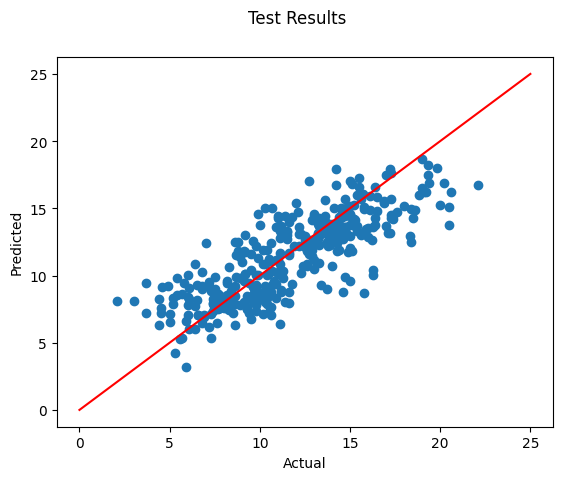

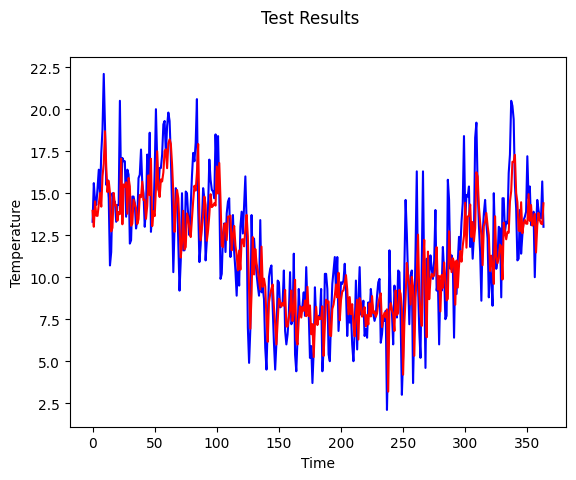

In [20]:
# show scatterplots of actual vs. predicted for train and test
# make a prediction
pred = model.predict(X_test)# the pred

# calculate MSE for the baseline model
from sklearn.metrics import mean_absolute_error
print('MAE: ', mean_absolute_error(y_test, pred))

actual = y_test # the actual
plt.scatter(x=actual, y=pred)
x = np.linspace(0,25) # 45 degree line from 0 to 25 (axes are the same)
plt.plot(x, x, color='red')
plt.suptitle('Test Results')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()
# looks pretty good!

# show timeseries plot on the train and validation data
plt.plot(np.arange(X_test.shape[0]), y_test, color='blue') # actual data
plt.plot(np.arange(X_test.shape[0]), pred, color='red') # predicted data
plt.suptitle('Test Results')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.show()

## Save the model and use it again

Reproducibility means more than a seed: **save the fitted model** so you (or a teammate, or your future self) can reload it and predict without retraining. Keras 3 saves to a single `.keras` file. The reloaded model must give *identical* predictions - we check.

In [21]:
from keras.models import load_model

model.save('Univariate_Temperature_RNN.keras')                 # one file: architecture + weights + optimizer state
reloaded = load_model('Univariate_Temperature_RNN.keras')

# same inputs, same answers?
import numpy as np
same = np.allclose(model.predict(X_test[:5], verbose=0), reloaded.predict(X_test[:5], verbose=0))
print('reloaded model reproduces the predictions:', same)
reloaded.summary()

reloaded model reproduces the predictions: True


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30)             │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,615 (45.38 KB)

 Trainable params: 3,871 (15.12 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,744 (30.25 KB)

# Baseline Model
What if you just use yesterday's value as the prediction?!

In [22]:
# baseline model - prediction is just the previous time step (a tough one to beat!)
df['Baseline'] = df['Temp'].shift(1)
df.head()

,Date,Temp,Baseline
0,1981-01-01,20.7,NaN
1,1981-01-02,17.9,20.7
2,1981-01-03,18.8,17.9
3,1981-01-04,14.6,18.8
4,1981-01-05,15.8,14.6


In [23]:
# if you wanted to see how this model does, use df['Baseline'] for the pred
# here's how I'd do it
y_test_baseline = df['Baseline'].tail(y_test.shape[0])
# check your work
y_test_baseline.shape

(364,)

In [24]:
# check shapes, looks good!
y_test.shape

(364,)

MAE:  2.0247252747252746


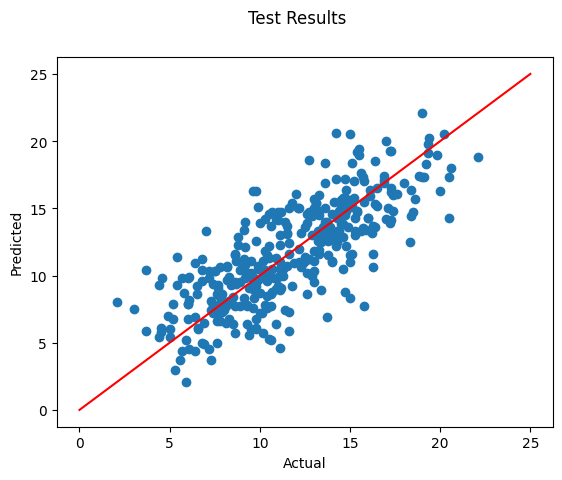

In [25]:
# now set this equal to pred and repeat code!



# show scatterplots of actual vs. predicted for train and test
# make a prediction
pred = y_test_baseline # the pred
actual = y_test # the actual

# calculate MSE for the baseline model
from sklearn.metrics import mean_absolute_error
print('MAE: ', mean_absolute_error(y_test, pred))


plt.scatter(x=actual, y=pred)
x = np.linspace(0,25) # 45 degree line from 0 to 25 (axes are the same)
plt.plot(x, x, color='red')
plt.suptitle('Test Results')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()
# looks pretty good!

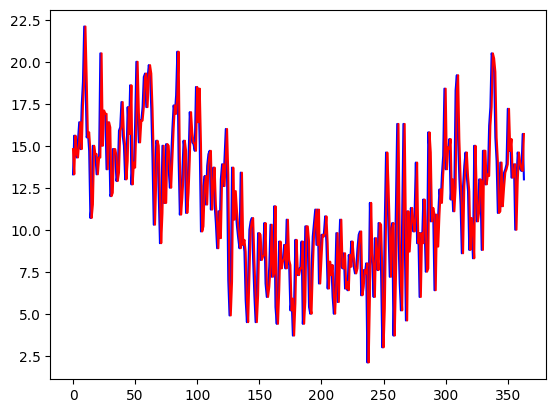

In [26]:
# show timeseries plot on the train and validation data
plt.plot(np.arange(X_test.shape[0]), y_test, color='blue') # actual data
plt.plot(np.arange(X_test.shape[0]), pred, color='red') # predicted data
plt.show()
# looks good, BUT it's not a smart model! all the data is just shifted.

In [27]:
# calculate MSE for the baseline model
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test, pred)

2.0247252747252746

In [28]:
# our RNN models beats the baseline model!
# don't be FOOLED by the line plot... or model is 20% better than a dumb model!